# ABM Experiments and Stress Testing
This notebook runs four experiments:
- Uncontrolled baselines
- Policy effectiveness
- Mean-field limit breakdown
- Emergence and phase transitions

In [3]:
from pathlib import Path
import json
import argparse
import sys
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import scripts.run_abm_experiments as rae
importlib.reload(rae)
from mfnn_control import ABMConfig

run_all_experiments = rae.run_all_experiments

FIG_DIR = ROOT / 'results' / 'figures' / 'abm'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_SIGMA = 1.0
ABM_SIGMA   = 1.0

SEEDS = [7, 9, 11, 13, 21]
ENCODERS = ['bins', 'cylindrical']
PRIMARY_ENCODER = 'cylindrical'
TOPOLOGY_NAMES = ['homogeneous', 'core_periphery', 'erdos_renyi']
PRETTY_NAMES = ['Homogeneous', 'Core-Periphery', 'Erdős-Rényi']
TOPOLOGY_PRETTY = dict(zip(TOPOLOGY_NAMES, PRETTY_NAMES))
T_CRIT_95 = {
    1: float('inf'), 2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776,
    6: 2.571, 7: 2.447, 8: 2.365, 9: 2.306, 10: 2.262,
}

def save_and_show(fig_name: str) -> None:
    fig = plt.gcf()
    out = FIG_DIR / f'{fig_name}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()
    plt.close(fig)


def mean_ci(values) -> list[float]:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return [float('nan'), float('nan')]
    mean = float(arr.mean())
    if arr.size == 1:
        return [mean, mean]
    t_crit = T_CRIT_95.get(int(arr.size), 1.96)
    half_width = float(t_crit * arr.std(ddof=1) / np.sqrt(arr.size))
    return [mean - half_width, mean + half_width]


def scalar_mean_and_ci(values) -> tuple[float, list[float]]:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float('nan'), [float('nan'), float('nan')]
    return float(arr.mean()), mean_ci(arr)


def concat_distributions(dicts, key):
    merged = []
    for item in dicts:
        merged.extend(item.get(key, []))
    return merged


def aggregate_stats_dicts(stats_list):
    aggregated = {}
    scalar_keys = ['mean_cascade_size', 'cascade_rate', 'mean_first_default_time']
    for key in scalar_keys:
        if all(key in stats for stats in stats_list):
            mean, ci = scalar_mean_and_ci([stats[key] for stats in stats_list])
            aggregated[key] = mean
            aggregated[f'{key}_ci'] = ci
    if any('cascade_size_distribution' in stats for stats in stats_list):
        aggregated['cascade_size_distribution'] = concat_distributions(stats_list, 'cascade_size_distribution')
    return aggregated


def aggregate_topology_metric_grid(rows_by_seed):
    id_key = 'N' if 'N' in rows_by_seed[0][0] else 'q'
    aggregated_rows = []
    for idx in range(len(rows_by_seed[0])):
        row = {id_key: rows_by_seed[0][idx][id_key], 'topologies': {}}
        for topo in TOPOLOGY_NAMES:
            topo_runs = [seed_rows[idx]['topologies'][topo] for seed_rows in rows_by_seed]
            topo_row = {}
            for key, value in topo_runs[0].items():
                if key.endswith('_ci'):
                    continue
                if isinstance(value, (int, float)):
                    mean, ci = scalar_mean_and_ci([run[key] for run in topo_runs])
                    topo_row[key] = mean
                    topo_row[f'{key}_ci'] = ci
                elif key.endswith('_distribution'):
                    topo_row[key] = concat_distributions(topo_runs, key)
            row['topologies'][topo] = topo_row
        aggregated_rows.append(row)
    return aggregated_rows


def aggregate_phase_rows(rows_by_seed):
    aggregated = []
    for idx in range(len(rows_by_seed[0])):
        row = {'q': rows_by_seed[0][idx]['q']}
        for key in ['cascade_rate', 'mean_cascade_size']:
            mean, ci = scalar_mean_and_ci([seed_rows[idx][key] for seed_rows in rows_by_seed])
            row[key] = mean
            row[f'{key}_ci'] = ci
        row['cascade_size_distribution'] = []
        for seed_rows in rows_by_seed:
            row['cascade_size_distribution'].extend(seed_rows[idx].get('cascade_size_distribution', []))
        aggregated.append(row)
    return aggregated


def aggregate_experiment_1(outputs):
    aggregated = {}
    for topo in TOPOLOGY_NAMES:
        topo_runs = [output['experiment_1_uncontrolled'][topo] for output in outputs]
        aggregated[topo] = {
            'hub_node': topo_runs[0]['hub_node'],
            'stats': aggregate_stats_dicts([run['stats'] for run in topo_runs]),
        }
    return aggregated


def aggregate_experiment_2(outputs):
    aggregated = {}
    for topo in TOPOLOGY_NAMES:
        topo_runs = [output['experiment_2_controlled'][topo] for output in outputs]
        topo_entry = {
            'uncontrolled': {
                'hub_node': topo_runs[0]['uncontrolled']['hub_node'],
                'stats': aggregate_stats_dicts([run['uncontrolled']['stats'] for run in topo_runs]),
            },
            'controlled': {
                'hub_node': topo_runs[0]['controlled']['hub_node'],
                'stats': aggregate_stats_dicts([run['controlled']['stats'] for run in topo_runs]),
            },
        }
        if 'heuristic' in topo_runs[0]:
            topo_entry['heuristic'] = {
                'hub_node': topo_runs[0]['heuristic']['hub_node'],
                'stats': aggregate_stats_dicts([run['heuristic']['stats'] for run in topo_runs]),
            }
        for key in ['cascade_reduction', 'cascade_size_reduction', 'heuristic_cascade_reduction', 'heuristic_cascade_size_reduction']:
            if all(key in run for run in topo_runs):
                mean, ci = scalar_mean_and_ci([run[key] for run in topo_runs])
                topo_entry[key] = mean
                topo_entry[f'{key}_ci'] = ci
        aggregated[topo] = topo_entry
    return aggregated


def aggregate_experiment_3(outputs):
    rows_vs_n = [output['experiment_3_limit_breakdown']['vs_N'] for output in outputs]
    rows_vs_q = [output['experiment_3_limit_breakdown']['vs_q'] for output in outputs]
    return {
        'vs_N': aggregate_topology_metric_grid(rows_vs_n),
        'vs_q': aggregate_topology_metric_grid(rows_vs_q),
    }


def aggregate_experiment_4(outputs):
    aggregated = {}
    for topo in TOPOLOGY_NAMES:
        topo_runs = [output['experiment_4_phase_transition'][topo] for output in outputs]
        entry = {
            'uncontrolled': aggregate_phase_rows([run['uncontrolled'] for run in topo_runs]),
            'controlled': aggregate_phase_rows([run['controlled'] for run in topo_runs]),
        }
        for key in ['critical_q_uncontrolled', 'critical_q_controlled']:
            values = [run[key] for run in topo_runs if run.get(key) is not None]
            if values:
                mean, ci = scalar_mean_and_ci(values)
                entry[key] = mean
                entry[f'{key}_ci'] = ci
            else:
                entry[key] = None
                entry[f'{key}_ci'] = [None, None]
        aggregated[topo] = entry
    return aggregated


def aggregate_experiment_5(exp5_by_seed):
    aggregated = []
    for sigma_idx in range(len(exp5_by_seed[0])):
        q_rows = []
        q_sweep_by_seed = [seed_rows[sigma_idx]['q_sweep'] for seed_rows in exp5_by_seed]
        for q_idx in range(len(q_sweep_by_seed[0])):
            row = {'q': q_sweep_by_seed[0][q_idx]['q']}
            for key in [
                'uncontrolled_cascade_rate', 'controlled_cascade_rate',
                'uncontrolled_mean_cascade_size', 'controlled_mean_cascade_size',
                'rate_reduction',
            ]:
                values = [seed_rows[q_idx][key] for seed_rows in q_sweep_by_seed]
                mean, ci = scalar_mean_and_ci(values)
                row[key] = mean
                row[f'{key}_ci'] = ci
            q_rows.append(row)
        sigma_entry = {
            'sigma': exp5_by_seed[0][sigma_idx]['sigma'],
            'q_sweep': q_rows,
        }
        for key in ['critical_q_uncontrolled', 'critical_q_controlled']:
            values = [seed_rows[sigma_idx][key] for seed_rows in exp5_by_seed if seed_rows[sigma_idx].get(key) is not None]
            if values:
                mean, ci = scalar_mean_and_ci(values)
                sigma_entry[key] = mean
                sigma_entry[f'{key}_ci'] = ci
            else:
                sigma_entry[key] = None
                sigma_entry[f'{key}_ci'] = [None, None]
        aggregated.append(sigma_entry)
    return aggregated


def aggregate_wasserstein(outputs):
    rows_by_seed = [output.get('experiment_wasserstein_convergence', []) for output in outputs]
    if not rows_by_seed or not rows_by_seed[0]:
        return []
    aggregated = []
    for idx in range(len(rows_by_seed[0])):
        row = {'N': rows_by_seed[0][idx]['N']}
        for key in ['w1_uncontrolled', 'w1_controlled']:
            mean, ci = scalar_mean_and_ci([seed_rows[idx][key] for seed_rows in rows_by_seed])
            row[key] = mean
            row[f'{key}_ci'] = ci
        aggregated.append(row)
    return aggregated


def aggregate_outputs(outputs, selected_encoder, encoder_screen):
    return {
        'selected_encoder': selected_encoder,
        'encoder_screen': encoder_screen,
        'seeds': [output['config']['args']['seed'] for output in outputs],
        'seed_outputs': outputs,
        'config': {
            'selected_encoder': selected_encoder,
            'seed_checkpoints': [output['config']['checkpoint'] for output in outputs],
            'args': dict(outputs[0]['config']['args']),
            'abm_config': dict(outputs[0]['config']['abm_config']),
        },
        'calibration': {
            'selected_q': scalar_mean_and_ci([output['calibration']['selected_q'] for output in outputs])[0],
            'selected_q_ci': mean_ci([output['calibration']['selected_q'] for output in outputs]),
            'per_seed': [output['calibration'] for output in outputs],
        },
        'experiment_1_uncontrolled': aggregate_experiment_1(outputs),
        'experiment_2_controlled': aggregate_experiment_2(outputs),
        'experiment_3_limit_breakdown': aggregate_experiment_3(outputs),
        'experiment_4_phase_transition': aggregate_experiment_4(outputs),
        'experiment_5_subcritical_rate_comparison': aggregate_experiment_5(
            [output['experiment_5_subcritical_rate_comparison'] for output in outputs]
        ),
        'experiment_wasserstein_convergence': aggregate_wasserstein(outputs),
    }


def checkpoint_for(encoder: str, seed: int) -> Path:
    return ROOT / 'results' / 'checkpoints' / f'systemic_risk_global_bsde_{encoder}_case_1_seed{seed}.pt'


def build_args(checkpoint: Path, seed: int, device: str, mc_paths: int) -> argparse.Namespace:
    return argparse.Namespace(
        checkpoint=str(checkpoint.relative_to(ROOT)),
        output_dir='results/abm',
        case='case_1',
        device=device,
        state_dim=1,
        steps=20,
        horizon=0.2,
        sigma=ABM_SIGMA,
        default_threshold=-0.5,
        target_cascade_rate=0.35,
        q_min=0.1,
        q_max=1.4,
        q_steps=14,
        agents=100,
        core_hubs=10,
        er_p=0.08,
        mc_paths=mc_paths,
        seed=seed,
        n_grid='10,30,100,300,1000',
        q_grid='0.4,0.6,0.8,1.0,1.2',
        phase_q_min=0.0,
        phase_q_max=2.0,
        phase_q_steps=21,
        subcrit_sigmas='0.2,0.5,1.0',
        subcrit_q_min=0.2,
        subcrit_q_max=2.0,
        subcrit_q_steps=19,
    )


def run_encoder_screen(seeds: list[int], device: str, mc_paths: int) -> list[dict]:
    """Screen both encoders for the comparison section. Main experiments always use PRIMARY_ENCODER."""
    screen_rows = []
    for encoder in ENCODERS:
        rows = []
        for seed in seeds:
            ckpt = checkpoint_for(encoder, seed)
            if not ckpt.exists():
                print(f'Skipping missing checkpoint: {ckpt.name}')
                continue
            args_screen = build_args(ckpt, seed, device=device, mc_paths=mc_paths)
            policy = rae.load_policy_from_checkpoint(ckpt, device)
            topologies = rae.build_topologies(args_screen.agents, args_screen.core_hubs, args_screen.er_p, device)
            q_values = torch.linspace(args_screen.q_min, args_screen.q_max, args_screen.q_steps).tolist()
            base_config = ABMConfig(
                horizon=args_screen.horizon, steps=args_screen.steps, sigma=args_screen.sigma,
                interaction_q=args_screen.q_min, state_dim=args_screen.state_dim,
                default_threshold=args_screen.default_threshold,
            )
            calibration = rae.calibrate_q(
                base_config, topologies['homogeneous'], args_screen.case,
                args_screen.mc_paths, args_screen.state_dim, device, q_values, args_screen.target_cascade_rate,
            )
            calibrated_config = ABMConfig(
                horizon=base_config.horizon, steps=base_config.steps, sigma=base_config.sigma,
                interaction_q=float(calibration['selected_q']), state_dim=base_config.state_dim,
                default_threshold=base_config.default_threshold,
            )
            exp2 = rae.experiment_2_controlled(
                calibrated_config, topologies, args_screen.case,
                args_screen.mc_paths, args_screen.state_dim, device, policy,
            )
            size_reductions = [exp2[topo]['cascade_size_reduction'] for topo in TOPOLOGY_NAMES]
            controlled_sizes = [exp2[topo]['controlled']['stats']['mean_cascade_size'] for topo in TOPOLOGY_NAMES]
            rows.append({
                'encoder': encoder, 'seed': seed, 'checkpoint': str(ckpt),
                'selected_q': float(calibration['selected_q']),
                'avg_size_reduction': float(np.mean(size_reductions)),
                'avg_controlled_size': float(np.mean(controlled_sizes)),
            })
        mean_reduction, reduction_ci = scalar_mean_and_ci([r['avg_size_reduction'] for r in rows])
        mean_size, size_ci = scalar_mean_and_ci([r['avg_controlled_size'] for r in rows])
        screen_rows.append({
            'encoder': encoder, 'n_runs': len(rows),
            'avg_size_reduction': mean_reduction, 'avg_size_reduction_ci': reduction_ci,
            'avg_controlled_size': mean_size, 'avg_controlled_size_ci': size_ci,
            'rows': rows,
        })
    return screen_rows


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print('Seeds:', SEEDS)
print(f'Primary encoder for ABM: {PRIMARY_ENCODER}')
print(f'Training sigma: {TRAIN_SIGMA}  |  ABM test sigma: {ABM_SIGMA}')
print('Multi-sigma sweep (Exp 5): {0.2, 0.5, 1.0}')


Device: cuda
Seeds: [7, 9, 11, 13, 21]
Primary encoder for ABM: cylindrical
Training sigma: 1.0  |  ABM test sigma: 1.0
Multi-sigma sweep (Exp 5): {0.2, 0.5, 1.0}


In [4]:
if device == 'cuda':
    torch.cuda.empty_cache()

mc_paths = 500
encoder_screen_mc_paths = min(300, mc_paths)

encoder_screen = run_encoder_screen(SEEDS, device=device, mc_paths=encoder_screen_mc_paths)

selected_encoder = PRIMARY_ENCODER

available_seeds = [seed for seed in SEEDS if checkpoint_for(selected_encoder, seed).exists()]
if not available_seeds:
    raise FileNotFoundError(f'No checkpoints found for encoder={selected_encoder!r}')

selected_checkpoints = {seed: checkpoint_for(selected_encoder, seed) for seed in available_seeds}
run_device = device
run_mc_paths = mc_paths
seed_outputs = []

for seed in tqdm(available_seeds, desc=f'Running ABM experiments for encoder={selected_encoder}'):
    checkpoint = selected_checkpoints[seed]
    args_seed = build_args(checkpoint, seed, device=run_device, mc_paths=run_mc_paths)
    try:
        seed_outputs.append(run_all_experiments(args_seed))
    except torch.OutOfMemoryError:
        if run_device == 'cuda':
            torch.cuda.empty_cache()
        run_device = 'cpu'
        run_mc_paths = min(200, mc_paths)
        args_seed = build_args(checkpoint, seed, device=run_device, mc_paths=run_mc_paths)
        seed_outputs.append(run_all_experiments(args_seed))

out = aggregate_outputs(seed_outputs, selected_encoder, encoder_screen)
out['run_device'] = run_device
out['mc_paths'] = run_mc_paths
out['available_seeds'] = available_seeds
out['selected_seed_checkpoints'] = {seed: str(path.relative_to(ROOT)) for seed, path in selected_checkpoints.items()}

args = build_args(selected_checkpoints[available_seeds[0]], available_seeds[0], device=run_device, mc_paths=run_mc_paths)
args.selected_encoder = selected_encoder
args.selected_seed_checkpoints = out['selected_seed_checkpoints']
args.active_seeds = available_seeds

Path(ROOT / args.output_dir).mkdir(parents=True, exist_ok=True)
out_path = ROOT / args.output_dir / 'abm_experiments_notebook.json'
out_path.write_text(json.dumps(out, indent=2), encoding='utf-8')

print('Saved:', out_path)
print(f'Selected encoder: {selected_encoder}')
print(f'Seeds evaluated: {available_seeds}')
print(f'Device used: {run_device}')
print(f'mc_paths per seed: {run_mc_paths}')
print(f"Calibrated q (mean across seeds): {out['calibration']['selected_q']:.3f}")
print(f"95% CI for calibrated q: {out['calibration']['selected_q_ci']}")
print('\nEncoder screen (for comparison - see final section):')
print(f"{'Encoder':<14} {'Runs':>4} {'Avg reduction':>16} {'95% CI':>24} {'Avg ctl size':>16}")
print('-' * 84)
for row in encoder_screen:
    ci = row['avg_size_reduction_ci']
    print(
        f"{row['encoder']:<14} {row['n_runs']:>4d} "
        f"{row['avg_size_reduction']:>16.3f} "
        f"[{ci[0]:.3f}, {ci[1]:.3f}] "
        f"{row['avg_controlled_size']:>16.3f}"
    )

Running ABM experiments for encoder=cylindrical: 100%|██████████| 5/5 [02:59<00:00, 35.99s/it]


Saved: C:\Users\adoni\Desktop\Interactions\project\results\abm\abm_experiments_notebook.json
Selected encoder: cylindrical
Seeds evaluated: [7, 9, 11, 13, 21]
Device used: cuda
mc_paths per seed: 500
Calibrated q (mean across seeds): 0.100
95% CI for calibrated q: [0.10000000149011612, 0.10000000149011612]

Encoder screen (for comparison - see final section):
Encoder        Runs    Avg reduction                   95% CI     Avg ctl size
------------------------------------------------------------------------------------
bins              5            3.271 [2.889, 3.653]           21.390
cylindrical       5            3.353 [3.079, 3.626]           21.311


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp1_uncontrolled.png


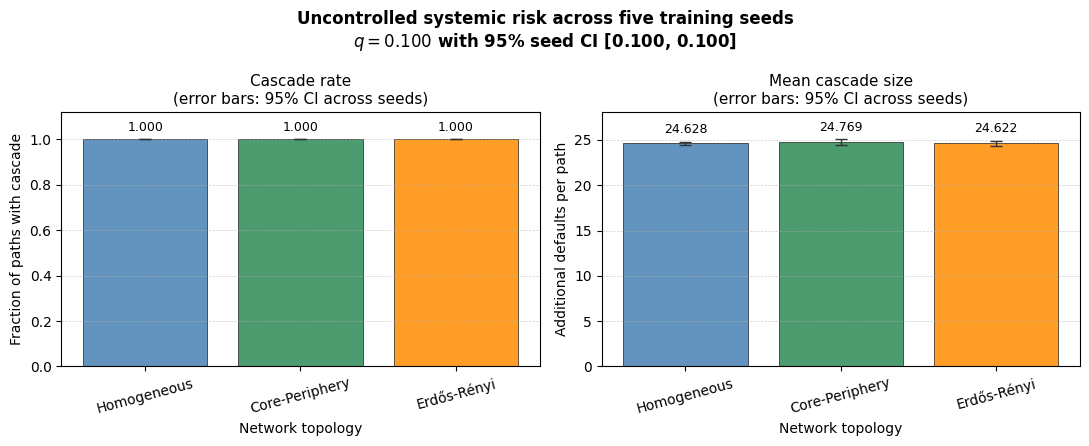

In [21]:
exp1 = out['experiment_1_uncontrolled']
names = TOPOLOGY_NAMES
pretty_names = PRETTY_NAMES
rates = [exp1[name]['stats']['cascade_rate'] for name in names]
sizes = [exp1[name]['stats']['mean_cascade_size'] for name in names]
rate_ci = [exp1[name]['stats'].get('cascade_rate_ci', [rate, rate]) for name, rate in zip(names, rates)]
size_ci = [exp1[name]['stats'].get('mean_cascade_size_ci', [size, size]) for name, size in zip(names, sizes)]
rate_err = [[max(0, rate - ci[0]) for rate, ci in zip(rates, rate_ci)], [max(0, ci[1] - rate) for rate, ci in zip(rates, rate_ci)]]
size_err = [[max(0, size - ci[0]) for size, ci in zip(sizes, size_ci)], [max(0, ci[1] - size) for size, ci in zip(sizes, size_ci)]]
calibrated_q = out['calibration']['selected_q']
calibrated_q_ci = out['calibration'].get('selected_q_ci', [calibrated_q, calibrated_q])

bar_colors = ['steelblue', 'seagreen', 'darkorange']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    'Uncontrolled systemic risk across five training seeds\n'
    f'$q = {calibrated_q:.3f}$ with 95% seed CI [{calibrated_q_ci[0]:.3f}, {calibrated_q_ci[1]:.3f}]',
    fontsize=12, fontweight='bold',
)

bc0 = axes[0].bar(
    pretty_names,
    rates,
    color=bar_colors,
    alpha=0.85,
    edgecolor='k',
    linewidth=0.5,
    yerr=rate_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
axes[0].bar_label(bc0, fmt='%.3f', padding=4, fontsize=9)
axes[0].set_title('Cascade rate\n(error bars: 95% CI across seeds)', fontsize=11)
axes[0].set_xlabel('Network topology')
axes[0].set_ylabel('Fraction of paths with cascade')
axes[0].set_ylim(0, min(1.15, max(rates) + max(rate_err[1]) + 0.12))
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

bc1 = axes[1].bar(
    pretty_names,
    sizes,
    color=bar_colors,
    alpha=0.85,
    edgecolor='k',
    linewidth=0.5,
    yerr=size_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
axes[1].bar_label(bc1, fmt='%.3f', padding=4, fontsize=9)
axes[1].set_title('Mean cascade size\n(error bars: 95% CI across seeds)', fontsize=11)
axes[1].set_xlabel('Network topology')
axes[1].set_ylabel('Additional defaults per path')
axes[1].set_ylim(0, max(sizes) + max(size_err[1]) + 3 if max(sizes) > 0 else 1.0)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
save_and_show('abm_exp1_uncontrolled')

Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp2_policy_effectiveness.png


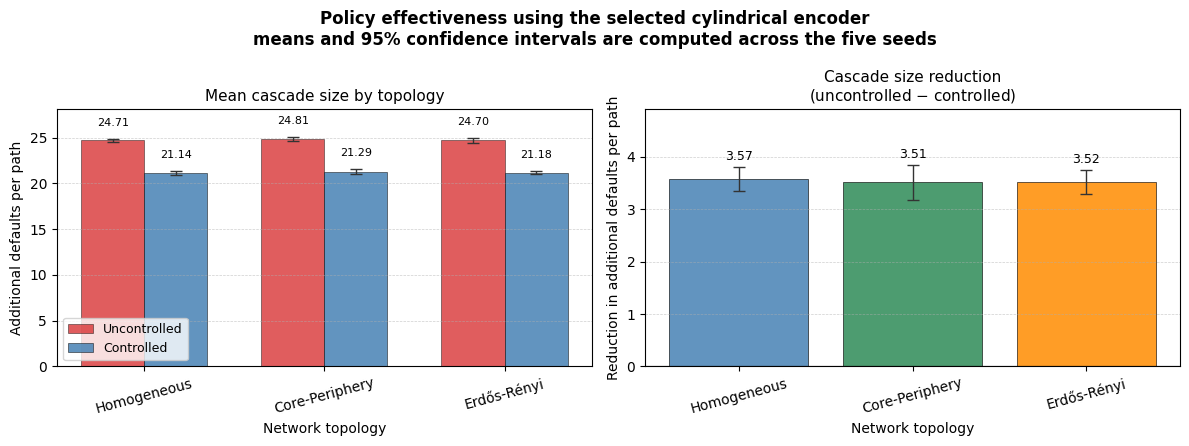


95% confidence intervals for mean cascade size:
  Homogeneous: unc=24.71 [24.54, 24.89]  ctl=21.14 [20.93, 21.35]  Δ=3.57 [3.34, 3.80]
  Core-Periphery: unc=24.81 [24.59, 25.03]  ctl=21.29 [21.07, 21.52]  Δ=3.51 [3.18, 3.85]
  Erdős-Rényi: unc=24.70 [24.42, 24.98]  ctl=21.18 [21.00, 21.36]  Δ=3.52 [3.29, 3.74]

Heuristic baseline size reductions (95% CI across seeds):
  Homogeneous: heuristic=21.14 [20.89, 21.40]  Δ=3.57 [3.33, 3.81]
  Core-Periphery: heuristic=24.12 [23.82, 24.41]  Δ=0.69 [0.45, 0.94]
  Erdős-Rényi: heuristic=24.48 [24.33, 24.63]  Δ=0.22 [0.03, 0.41]


In [23]:
exp2 = out['experiment_2_controlled']
pretty_names = PRETTY_NAMES

uncontrolled_sizes = [exp2[name]['uncontrolled']['stats']['mean_cascade_size'] for name in names]
controlled_sizes = [exp2[name]['controlled']['stats']['mean_cascade_size'] for name in names]
size_reductions = [exp2[name]['cascade_size_reduction'] for name in names]

u_size_ci = [exp2[name]['uncontrolled']['stats'].get('mean_cascade_size_ci', [value, value]) for name, value in zip(names, uncontrolled_sizes)]
c_size_ci = [exp2[name]['controlled']['stats'].get('mean_cascade_size_ci', [value, value]) for name, value in zip(names, controlled_sizes)]
red_ci = [exp2[name].get('cascade_size_reduction_ci', [value, value]) for name, value in zip(names, size_reductions)]

u_size_err = [[max(0, value - ci[0]) for value, ci in zip(uncontrolled_sizes, u_size_ci)], [max(0, ci[1] - value) for value, ci in zip(uncontrolled_sizes, u_size_ci)]]
c_size_err = [[max(0, value - ci[0]) for value, ci in zip(controlled_sizes, c_size_ci)], [max(0, ci[1] - value) for value, ci in zip(controlled_sizes, c_size_ci)]]
red_err = [[max(0, value - ci[0]) for value, ci in zip(size_reductions, red_ci)], [max(0, ci[1] - value) for value, ci in zip(size_reductions, red_ci)]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(
    f'Policy effectiveness using the selected {out["selected_encoder"]} encoder\n'
    'means and 95% confidence intervals are computed across the five seeds',
    fontsize=12, fontweight='bold',
)
width = 0.35
x = list(range(len(names)))

bc1 = axes[0].bar(
    [i - width / 2 for i in x],
    uncontrolled_sizes,
    width=width,
    label='Uncontrolled',
    color='#d62728',
    alpha=0.75,
    edgecolor='k',
    linewidth=0.4,
    yerr=u_size_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
bc2 = axes[0].bar(
    [i + width / 2 for i in x],
    controlled_sizes,
    width=width,
    label='Controlled',
    color='steelblue',
    alpha=0.85,
    edgecolor='k',
    linewidth=0.4,
    yerr=c_size_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
axes[0].bar_label(bc1, fmt='%.2f', padding=8, fontsize=8)
axes[0].bar_label(bc2, fmt='%.2f', padding=8, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pretty_names, rotation=15)
axes[0].set_ylim(0, max(uncontrolled_sizes + controlled_sizes) + max(u_size_err[1] + c_size_err[1]) + 3)
axes[0].set_title('Mean cascade size by topology', fontsize=11)
axes[0].set_xlabel('Network topology')
axes[0].set_ylabel('Additional defaults per path')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', ls='--', lw=0.5, alpha=0.6)

bc = axes[1].bar(
    pretty_names,
    size_reductions,
    color=['steelblue', 'seagreen', 'darkorange'],
    alpha=0.85,
    edgecolor='k',
    linewidth=0.5,
    yerr=red_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
axes[1].bar_label(bc, fmt='%.2f', padding=3, fontsize=9)
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].set_title('Cascade size reduction\n(uncontrolled $-$ controlled)', fontsize=11)
axes[1].set_xlabel('Network topology')
axes[1].set_ylabel('Reduction in additional defaults per path')
axes[1].set_ylim(min(0, min(size_reductions) - max(red_err[0]) - 0.2), max(size_reductions) + max(red_err[1]) + 1)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', ls='--', lw=0.5, alpha=0.6)

plt.tight_layout()
save_and_show('abm_exp2_policy_effectiveness')

print('\n95% confidence intervals for mean cascade size:')
for name, pretty_name in zip(names, pretty_names):
    u_ci = exp2[name]['uncontrolled']['stats'].get('mean_cascade_size_ci', [None, None])
    c_ci = exp2[name]['controlled']['stats'].get('mean_cascade_size_ci', [None, None])
    red_ci_single = exp2[name].get('cascade_size_reduction_ci', [None, None])
    u_val = exp2[name]['uncontrolled']['stats']['mean_cascade_size']
    c_val = exp2[name]['controlled']['stats']['mean_cascade_size']
    red_val = exp2[name]['cascade_size_reduction']
    print(
        f"  {pretty_name}: unc={u_val:.2f} [{u_ci[0]:.2f}, {u_ci[1]:.2f}]  "
        f"ctl={c_val:.2f} [{c_ci[0]:.2f}, {c_ci[1]:.2f}]  "
        f"Δ={red_val:.2f} [{red_ci_single[0]:.2f}, {red_ci_single[1]:.2f}]"
    )

if 'heuristic' in exp2[names[0]]:
    print('\nHeuristic baseline size reductions (95% CI across seeds):')
    for name, pretty_name in zip(names, pretty_names):
        h_stats = exp2[name]['heuristic']['stats']
        h_ci = h_stats.get('mean_cascade_size_ci', [h_stats['mean_cascade_size'], h_stats['mean_cascade_size']])
        h_red = exp2[name].get('heuristic_cascade_size_reduction')
        h_red_ci = exp2[name].get('heuristic_cascade_size_reduction_ci', [h_red, h_red])
        print(
            f"  {pretty_name}: heuristic={h_stats['mean_cascade_size']:.2f} [{h_ci[0]:.2f}, {h_ci[1]:.2f}]  "
            f"Δ={h_red:.2f} [{h_red_ci[0]:.2f}, {h_red_ci[1]:.2f}]"
        )

Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp3_limit_breakdown.png


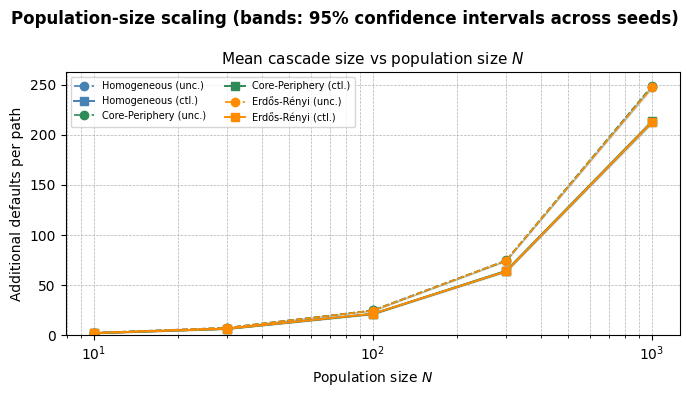

Topology        | N          | Unc. Mean  | Unc. CI (Lo, Hi)       | Ctl. Mean  | Ctl. CI (Lo, Hi)      
--------------------------------------------------------------------------------------------------------
Homogeneous     | 10         | 2.236      | (2.120, 2.352)         | 2.011      | (1.954, 2.069)        
Homogeneous     | 30         | 7.263      | (7.110, 7.415)         | 6.295      | (6.233, 6.357)        
Homogeneous     | 100        | 24.688     | (24.420, 24.957)       | 21.248     | (20.877, 21.619)      
Homogeneous     | 300        | 74.349     | (73.909, 74.789)       | 63.740     | (63.340, 64.141)      
Homogeneous     | 1000       | 248.226    | (246.793, 249.659)     | 213.126    | (211.712, 214.540)    
Core-Periphery  | 10         | 2.242      | (2.216, 2.269)         | 2.006      | (1.939, 2.073)        
Core-Periphery  | 30         | 7.210      | (7.146, 7.273)         | 6.352      | (6.305, 6.399)        
Core-Periphery  | 100        | 24.670     | (24.368, 24

In [25]:
import numpy as np

exp3 = out['experiment_3_limit_breakdown']
vs_n = exp3['vs_N']
n_values = [item['N'] for item in vs_n]

topo_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}
pretty = {'homogeneous': 'Homogeneous', 'core_periphery': 'Core-Periphery', 'erdos_renyi': 'Erdős-Rényi'}

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
fig.suptitle('Population-size scaling (bands: 95% confidence intervals across seeds)', fontsize=12, fontweight='bold')

for name in names:
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_n]
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_n]
    u_lo = [item['topologies'][name].get('uncontrolled_mean_cascade_size_ci', [u, u])[0] for item, u in zip(vs_n, u_series)]
    u_hi = [item['topologies'][name].get('uncontrolled_mean_cascade_size_ci', [u, u])[1] for item, u in zip(vs_n, u_series)]
    c_lo = [item['topologies'][name].get('controlled_mean_cascade_size_ci', [c, c])[0] for item, c in zip(vs_n, c_series)]
    c_hi = [item['topologies'][name].get('controlled_mean_cascade_size_ci', [c, c])[1] for item, c in zip(vs_n, c_series)]
    col = topo_colors[name]
    ax.plot(n_values, u_series, marker='o', linestyle='--', color=col, lw=1.2, label=f'{pretty[name]} (unc.)')
    ax.fill_between(n_values, u_lo, u_hi, color=col, alpha=0.15)
    ax.plot(n_values, c_series, marker='s', linestyle='-', color=col, lw=1.4, label=f'{pretty[name]} (ctl.)')
    ax.fill_between(n_values, c_lo, c_hi, color=col, alpha=0.20)

ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_title('Mean cascade size vs population size $N$', fontsize=11)
ax.set_xlabel('Population size $N$')
ax.set_ylabel('Additional defaults per path')
ax.legend(ncol=2, fontsize=7)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
save_and_show('abm_exp3_limit_breakdown')


header = f"{'Topology':<15} | {'N':<10} | {'Unc. Mean':<10} | {'Unc. CI (Lo, Hi)':<22} | {'Ctl. Mean':<10} | {'Ctl. CI (Lo, Hi)':<22}"
print(header)
print("-" * len(header))

for name in names:
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_n]
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_n]
    u_lo = [item['topologies'][name].get('uncontrolled_mean_cascade_size_ci', [u, u])[0] for item, u in zip(vs_n, u_series)]
    u_hi = [item['topologies'][name].get('uncontrolled_mean_cascade_size_ci', [u, u])[1] for item, u in zip(vs_n, u_series)]
    c_lo = [item['topologies'][name].get('controlled_mean_cascade_size_ci', [c, c])[0] for item, c in zip(vs_n, c_series)]
    c_hi = [item['topologies'][name].get('controlled_mean_cascade_size_ci', [c, c])[1] for item, c in zip(vs_n, c_series)]

    for i, n in enumerate(n_values):
        topo_name = pretty.get(name, name)
        u_ci_str = f"({u_lo[i]:.3f}, {u_hi[i]:.3f})"
        c_ci_str = f"({c_lo[i]:.3f}, {c_hi[i]:.3f})"
        print(f"{topo_name:<15} | {n:<10} | {u_series[i]:<10.3f} | {u_ci_str:<22} | {c_series[i]:<10.3f} | {c_ci_str:<22}")


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp3_proxy_cost_and_rate.png


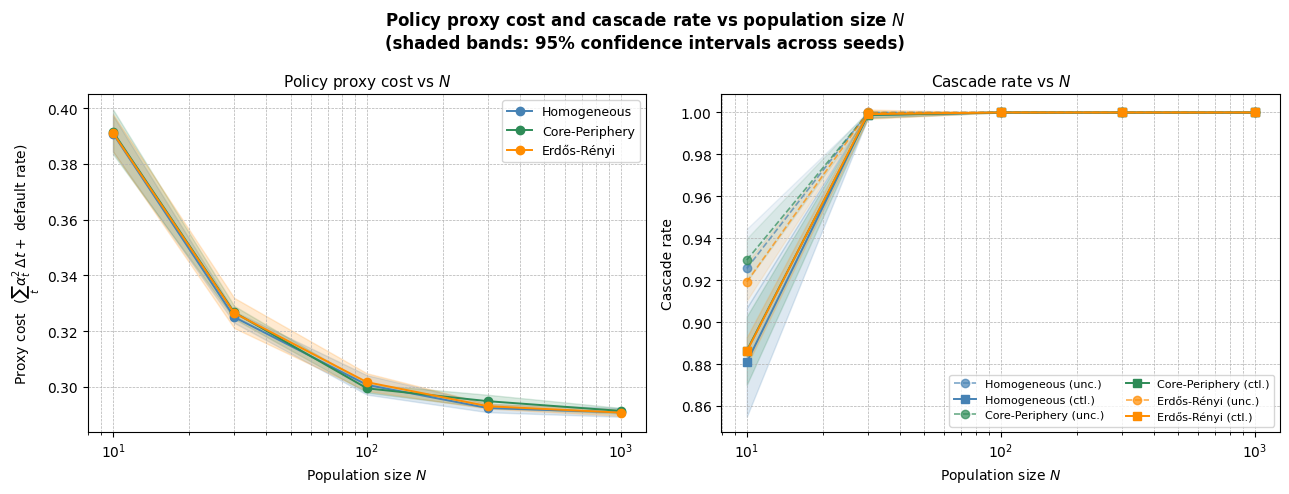

Proxy cost vs N (homogeneous):
  N=   10: proxy_cost=0.3909 [0.3844, 0.3974]
  N=   30: proxy_cost=0.3250 [0.3230, 0.3271]
  N=  100: proxy_cost=0.3006 [0.2972, 0.3041]
  N=  300: proxy_cost=0.2923 [0.2908, 0.2938]
  N= 1000: proxy_cost=0.2908 [0.2892, 0.2924]


In [8]:
topo_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}
pretty = {'homogeneous': 'Homogeneous', 'core_periphery': 'Core-Periphery', 'erdos_renyi': 'Erdős-Rényi'}

n_values_plot = [item['N'] for item in vs_n]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Policy proxy cost and cascade rate vs population size $N$\n'
    '(shaded bands: 95% confidence intervals across seeds)',
    fontsize=12, fontweight='bold',
)

for name in names:
    proxy_costs = [item['topologies'][name]['controlled_proxy_cost'] for item in vs_n]
    proxy_ci = [item['topologies'][name].get('controlled_proxy_cost_ci', [value, value]) for item, value in zip(vs_n, proxy_costs)]
    proxy_lo = [ci[0] for ci in proxy_ci]
    proxy_hi = [ci[1] for ci in proxy_ci]

    ctrl_rates = [item['topologies'][name]['controlled_cascade_rate'] for item in vs_n]
    ctrl_ci = [item['topologies'][name].get('controlled_cascade_rate_ci', [value, value]) for item, value in zip(vs_n, ctrl_rates)]
    ctrl_lo = [ci[0] for ci in ctrl_ci]
    ctrl_hi = [ci[1] for ci in ctrl_ci]

    unc_rates = [item['topologies'][name]['uncontrolled_cascade_rate'] for item in vs_n]
    unc_ci = [item['topologies'][name].get('uncontrolled_cascade_rate_ci', [value, value]) for item, value in zip(vs_n, unc_rates)]
    unc_lo = [ci[0] for ci in unc_ci]
    unc_hi = [ci[1] for ci in unc_ci]

    color = topo_colors[name]
    axes[0].plot(n_values_plot, proxy_costs, marker='o', lw=1.4, label=pretty[name], color=color)
    axes[0].fill_between(n_values_plot, proxy_lo, proxy_hi, color=color, alpha=0.18)

    axes[1].plot(n_values_plot, unc_rates, marker='o', lw=1.2, ls='--', color=color, alpha=0.7, label=f'{pretty[name]} (unc.)')
    axes[1].fill_between(n_values_plot, unc_lo, unc_hi, color=color, alpha=0.10)
    axes[1].plot(n_values_plot, ctrl_rates, marker='s', lw=1.4, color=color, label=f'{pretty[name]} (ctl.)')
    axes[1].fill_between(n_values_plot, ctrl_lo, ctrl_hi, color=color, alpha=0.18)

axes[0].set_xscale('log')
axes[0].set_xlabel('Population size $N$')
axes[0].set_ylabel(r'Proxy cost  ($\sum_t \alpha_t^2\,\Delta t + $ default rate)')
axes[0].set_title('Policy proxy cost vs $N$', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xscale('log')
axes[1].set_xlabel('Population size $N$')
axes[1].set_ylabel('Cascade rate')
axes[1].set_title('Cascade rate vs $N$', fontsize=11)
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
save_and_show('abm_exp3_proxy_cost_and_rate')

print('Proxy cost vs N (homogeneous):')
for item in vs_n:
    cost = item['topologies']['homogeneous']['controlled_proxy_cost']
    ci = item['topologies']['homogeneous'].get('controlled_proxy_cost_ci', [cost, cost])
    print(f"  N={item['N']:>5}: proxy_cost={cost:.4f} [{ci[0]:.4f}, {ci[1]:.4f}]")

W1 log-log slope (unc): -1.120  (Fournier-Guillin prediction: -0.5)
W1 log-log slope (ctl): -1.046  (Fournier-Guillin prediction: -0.5)
Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_wasserstein_convergence.png


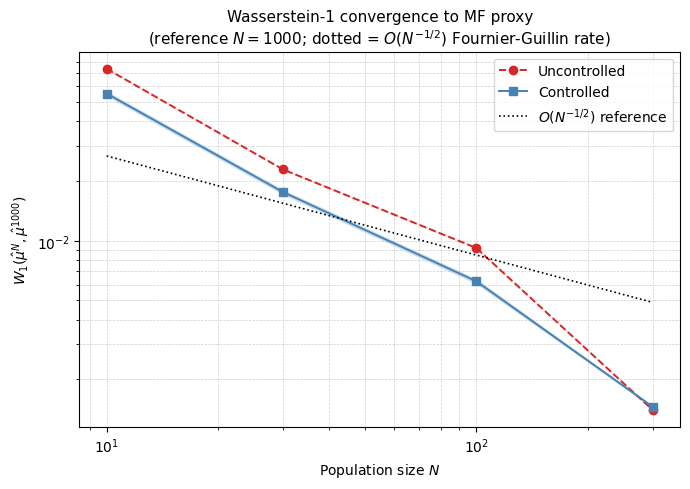

In [9]:
wass_data = out.get('experiment_wasserstein_convergence', [])
if not wass_data:
    print('Wasserstein data not found in results.')
else:
    n_ref_w = max(r['N'] for r in wass_data)
    n_plot = [r['N'] for r in wass_data if r['N'] < n_ref_w]
    w1_unc = [r['w1_uncontrolled'] for r in wass_data if r['N'] < n_ref_w]
    w1_ctl = [r['w1_controlled'] for r in wass_data if r['N'] < n_ref_w]
    w1_unc_lo = [r.get('w1_uncontrolled_ci', [value, value])[0] for r, value in zip([r for r in wass_data if r['N'] < n_ref_w], w1_unc)]
    w1_unc_hi = [r.get('w1_uncontrolled_ci', [value, value])[1] for r, value in zip([r for r in wass_data if r['N'] < n_ref_w], w1_unc)]
    w1_ctl_lo = [r.get('w1_controlled_ci', [value, value])[0] for r, value in zip([r for r in wass_data if r['N'] < n_ref_w], w1_ctl)]
    w1_ctl_hi = [r.get('w1_controlled_ci', [value, value])[1] for r, value in zip([r for r in wass_data if r['N'] < n_ref_w], w1_ctl)]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(n_plot, w1_unc, 'o--', color='#d62728', lw=1.4, label='Uncontrolled')
    ax.fill_between(n_plot, w1_unc_lo, w1_unc_hi, color='#d62728', alpha=0.12)
    ax.loglog(n_plot, w1_ctl, 's-', color='steelblue', lw=1.4, label='Controlled')
    ax.fill_between(n_plot, w1_ctl_lo, w1_ctl_hi, color='steelblue', alpha=0.18)

    n_arr = np.array(n_plot, dtype=float)
    ref_level = np.nanmean([w for w in w1_unc if w > 0]) * (n_arr[0] ** 0.5)
    ax.loglog(n_arr, ref_level * n_arr ** -0.5, 'k:', lw=1.2, label=r'$O(N^{-1/2})$ reference')

    for vals, label in [(w1_unc, 'unc'), (w1_ctl, 'ctl')]:
        valid = [(np.log(n), np.log(w)) for n, w in zip(n_plot, vals) if w > 0]
        if len(valid) >= 2:
            log_n, log_w = zip(*valid)
            slope = np.polyfit(log_n, log_w, 1)[0]
            print(f'W1 log-log slope ({label}): {slope:.3f}  (Fournier-Guillin prediction: -0.5)')

    ax.set_xlabel('Population size $N$')
    ax.set_ylabel(r'$W_1(\hat\mu^N, \hat\mu^{1000})$')
    ax.set_title(
        'Wasserstein-1 convergence to MF proxy\n'
        r'(reference $N=1000$; dotted = $O(N^{-1/2})$ Fournier-Guillin rate)',
        fontsize=11,
    )
    ax.legend(fontsize=10)
    ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.6)
    plt.tight_layout()
    save_and_show('abm_wasserstein_convergence')

## Coupling sweep and phase transition (Experiment 4)

We sweep $q \in [0, 2]$ using the **same parameters as Experiments 1–2**: $\sigma = 0.2$, $\theta_{\rm def} = -0.5$, Case 1 initial law, hub-node shock at $\theta_{\rm def} - 0.2$, $N = 100$ agents.  This makes the sweep directly comparable to the primary results.

Near the critical coupling $q^*$, the system exhibits a subcritical-to-supercritical phase transition: cascade rates are near zero for $q \ll q^*$ and rise steeply above it.  The controlled policy shifts the critical coupling rightward on all three topologies.

For the homogeneous topology at near-critical $q$, the cascade-size distribution is characterised by a **goodness-of-fit comparison** (next cell): exponential, log-normal, and Pareto distributions are fitted by MLE and ranked by AIC, identifying the best-fitting tail model.


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp4_phase_transition.png


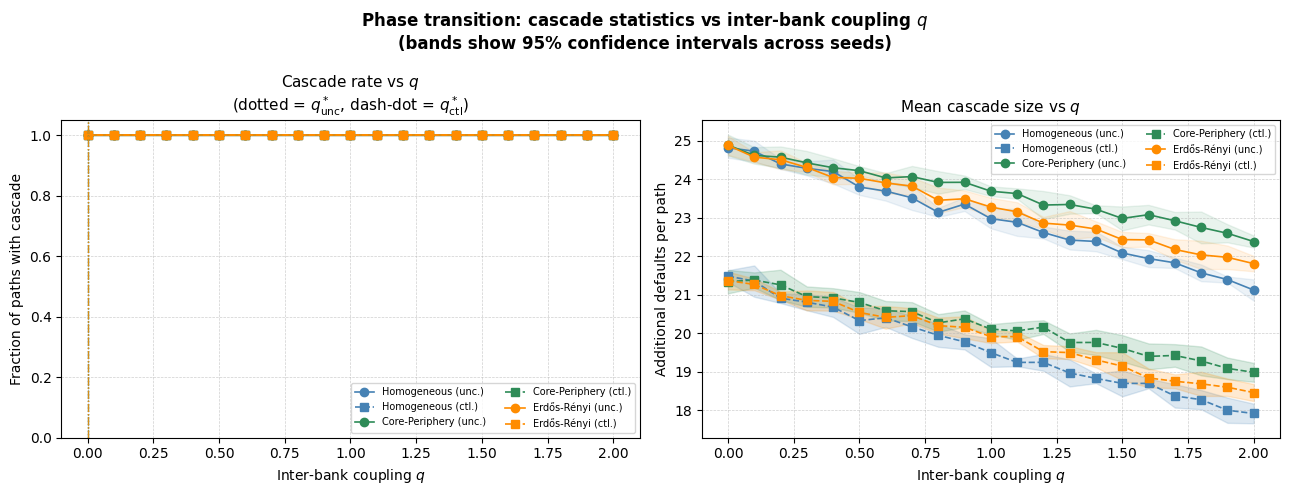

homogeneous: q*_unc=0.0 [0.0, 0.0], q*_ctl=0.0 [0.0, 0.0]
core_periphery: q*_unc=0.0 [0.0, 0.0], q*_ctl=0.0 [0.0, 0.0]
erdos_renyi: q*_unc=0.0 [0.0, 0.0], q*_ctl=0.0 [0.0, 0.0]


In [10]:
exp4 = out['experiment_4_phase_transition']
pretty = {'homogeneous': 'Homogeneous', 'core_periphery': 'Core-Periphery', 'erdos_renyi': 'Erdős-Rényi'}
colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Phase transition: cascade statistics vs inter-bank coupling $q$\n'
    '(bands show 95% confidence intervals across seeds)',
    fontsize=12, fontweight='bold',
)

for topo_name, topo_data in exp4.items():
    unc4_topo = topo_data['uncontrolled']
    ctl4_topo = topo_data['controlled']
    q4 = [row['q'] for row in unc4_topo]
    color = colors.get(topo_name, 'grey')
    label = pretty.get(topo_name, topo_name)

    unc_rate = [row['cascade_rate'] for row in unc4_topo]
    ctl_rate = [row['cascade_rate'] for row in ctl4_topo]
    unc_rate_lo = [row.get('cascade_rate_ci', [value, value])[0] for row, value in zip(unc4_topo, unc_rate)]
    unc_rate_hi = [row.get('cascade_rate_ci', [value, value])[1] for row, value in zip(unc4_topo, unc_rate)]
    ctl_rate_lo = [row.get('cascade_rate_ci', [value, value])[0] for row, value in zip(ctl4_topo, ctl_rate)]
    ctl_rate_hi = [row.get('cascade_rate_ci', [value, value])[1] for row, value in zip(ctl4_topo, ctl_rate)]

    unc_size = [row['mean_cascade_size'] for row in unc4_topo]
    ctl_size = [row['mean_cascade_size'] for row in ctl4_topo]
    unc_size_lo = [row.get('mean_cascade_size_ci', [value, value])[0] for row, value in zip(unc4_topo, unc_size)]
    unc_size_hi = [row.get('mean_cascade_size_ci', [value, value])[1] for row, value in zip(unc4_topo, unc_size)]
    ctl_size_lo = [row.get('mean_cascade_size_ci', [value, value])[0] for row, value in zip(ctl4_topo, ctl_size)]
    ctl_size_hi = [row.get('mean_cascade_size_ci', [value, value])[1] for row, value in zip(ctl4_topo, ctl_size)]

    axes[0].plot(q4, unc_rate, marker='o', color=color, lw=1.2, label=f'{label} (unc.)')
    axes[0].fill_between(q4, unc_rate_lo, unc_rate_hi, color=color, alpha=0.10)
    axes[0].plot(q4, ctl_rate, marker='s', color=color, lw=1.2, ls='--', label=f'{label} (ctl.)')
    axes[0].fill_between(q4, ctl_rate_lo, ctl_rate_hi, color=color, alpha=0.18)

    axes[1].plot(q4, unc_size, marker='o', color=color, lw=1.2, label=f'{label} (unc.)')
    axes[1].fill_between(q4, unc_size_lo, unc_size_hi, color=color, alpha=0.10)
    axes[1].plot(q4, ctl_size, marker='s', color=color, lw=1.2, ls='--', label=f'{label} (ctl.)')
    axes[1].fill_between(q4, ctl_size_lo, ctl_size_hi, color=color, alpha=0.18)

for topo_name, topo_data in exp4.items():
    cq_unc = topo_data.get('critical_q_uncontrolled')
    cq_ctl = topo_data.get('critical_q_controlled')
    color = colors.get(topo_name, 'grey')
    if cq_unc is not None:
        axes[0].axvline(cq_unc, color=color, ls=':', lw=0.9, alpha=0.7)
    if cq_ctl is not None:
        axes[0].axvline(cq_ctl, color=color, ls='-.', lw=0.9, alpha=0.7)

axes[0].set_xlabel('Inter-bank coupling $q$')
axes[0].set_ylabel('Fraction of paths with cascade')
axes[0].set_title(
    'Cascade rate vs $q$\n'
    r'(dotted = $q^*_{\rm unc}$, dash-dot = $q^*_{\rm ctl}$)',
    fontsize=11,
)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, ls='--', lw=0.5, alpha=0.6)

axes[1].set_xlabel('Inter-bank coupling $q$')
axes[1].set_ylabel('Additional defaults per path')
axes[1].set_title('Mean cascade size vs $q$', fontsize=11)
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, ls='--', lw=0.5, alpha=0.6)

plt.tight_layout()
save_and_show('abm_exp4_phase_transition')

for topo_name, topo_data in exp4.items():
    unc_ci = topo_data.get('critical_q_uncontrolled_ci', [None, None])
    ctl_ci = topo_data.get('critical_q_controlled_ci', [None, None])
    print(
        f"{topo_name}: q*_unc={topo_data.get('critical_q_uncontrolled')} [{unc_ci[0]}, {unc_ci[1]}], "
        f"q*_ctl={topo_data.get('critical_q_controlled')} [{ctl_ci[0]}, {ctl_ci[1]}]"
    )

unc4 = exp4['homogeneous']['uncontrolled']
ctl4 = exp4['homogeneous']['controlled']
q4 = [row['q'] for row in unc4]
cq_unc = exp4['homogeneous'].get('critical_q_uncontrolled')
cq_ctl = exp4['homogeneous'].get('critical_q_controlled')

Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp4_loglog_distributions_easy.png


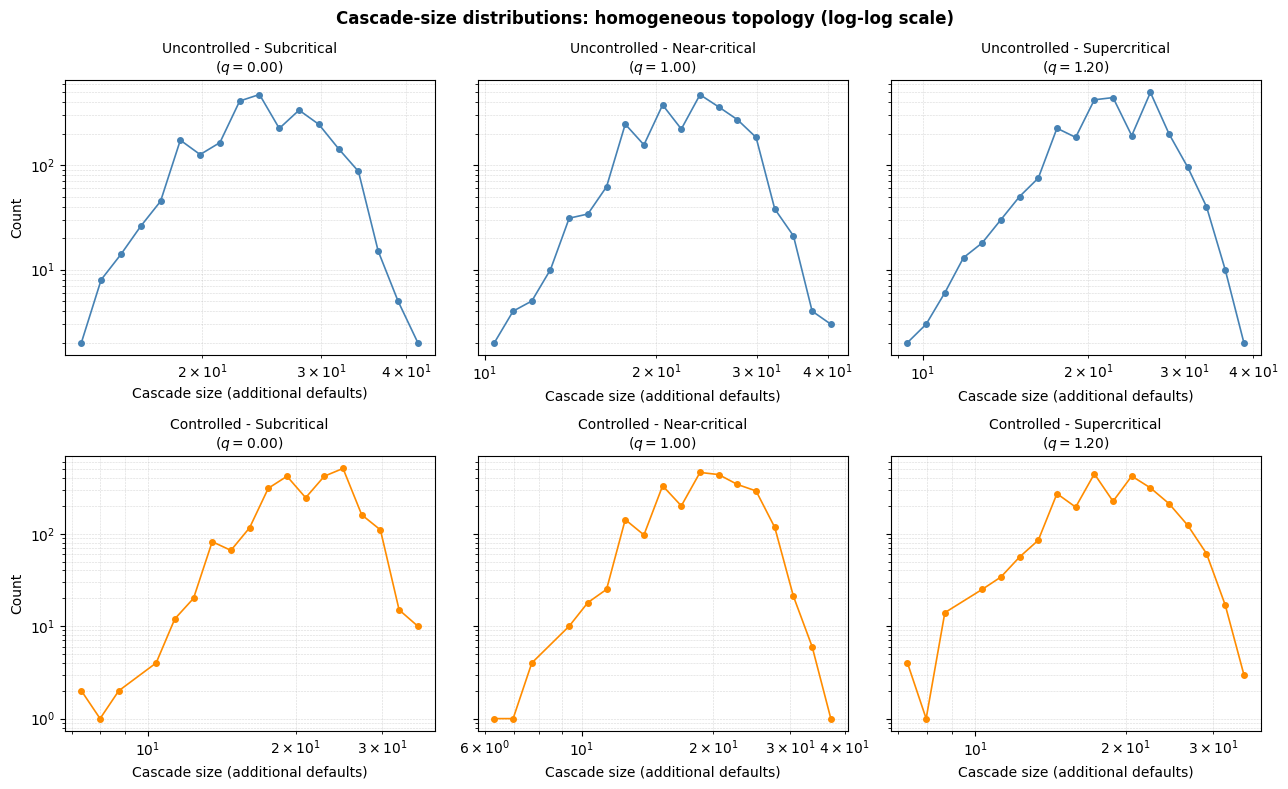

In [11]:
import numpy as np

q4_arr = q4
crit_q = cq_unc

below_idx = max((i for i, q in enumerate(q4_arr) if q < (crit_q or 0)), default=0)
at_idx    = min(range(len(q4_arr)), key=lambda i: abs(q4_arr[i] - (crit_q or q4_arr[len(q4_arr)//2])))
above_idx = min(at_idx + 2, len(q4_arr) - 1)

reg_labels = ['Subcritical', 'Near-critical', 'Supercritical']
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey='row')
fig.suptitle(
    'Cascade-size distributions: homogeneous topology (log-log scale)',
    fontsize=12, fontweight='bold',
)

for col, (idx, qlabel) in enumerate(zip([below_idx, at_idx, above_idx], reg_labels)):
    for row, (data, row_label, color) in enumerate([
        (unc4, 'Uncontrolled', 'steelblue'),
        (ctl4, 'Controlled',   'darkorange'),
    ]):
        ax = axes[row][col]
        sizes = [s for s in data[idx]['cascade_size_distribution'] if s > 0]
        if sizes:
            log_min = np.log10(max(min(sizes), 1e-1))
            log_max = np.log10(max(sizes) + 1)
            if log_max > log_min:
                bins = np.logspace(log_min, log_max, 20)
                counts, edges = np.histogram(sizes, bins=bins)
                centers = 0.5 * (edges[:-1] + edges[1:])
                mask = counts > 0
                ax.loglog(centers[mask], counts[mask], marker='o', markersize=4, lw=1.2, color=color)
            else:
                ax.text(0.5, 0.5, 'all same size', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9)
        else:
            ax.text(0.5, 0.5, 'no cascades', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_title(f'{row_label} - {qlabel}\n($q = {q4_arr[idx]:.2f}$)', fontsize=10)
        ax.set_xlabel('Cascade size (additional defaults)')
        if col == 0:
            ax.set_ylabel('Count')
        ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)

plt.tight_layout()
save_and_show('abm_exp4_loglog_distributions_easy')


Near-critical q = 0.00  |  non-zero cascade events: 2500

Goodness-of-fit comparison (homogeneous, uncontrolled, q = 0.00):
  n = 2500  (sizes >= x_min = 1.0)
  Model               AIC     ΔAIC   KS p-val  (best = lognormal)
  --------------------------------------------------
  exponential    20855.22 10974.54     0.0000
  lognormal       9880.68     0.00     0.0000  ★
  pareto         26792.02 16911.35     0.0000
Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_tailgof.png


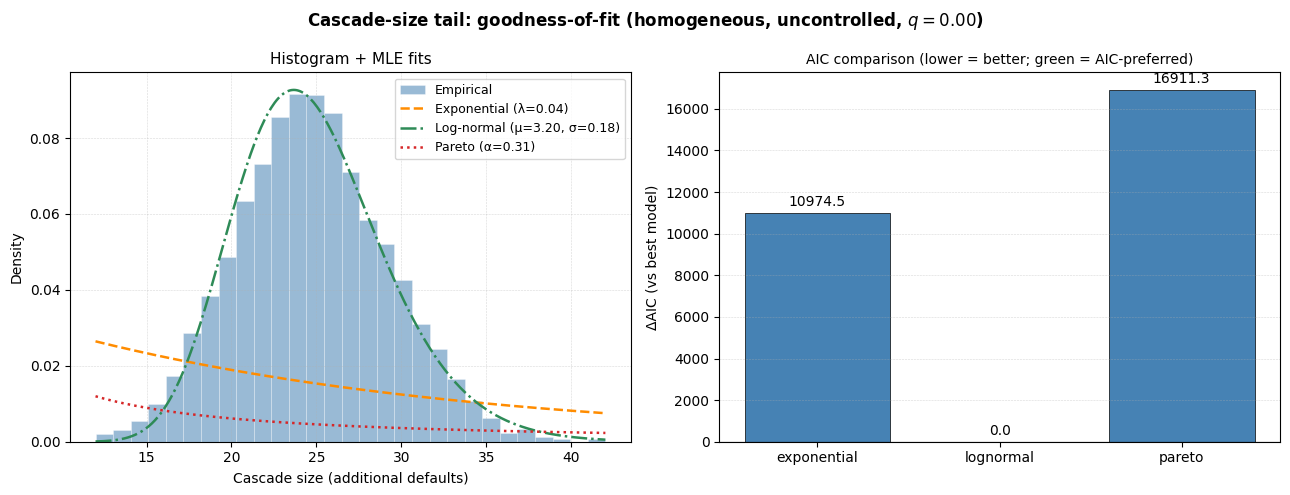

In [12]:
import numpy as np
import importlib
importlib.reload(rae)

# Locate near-critical q for homogeneous topology (uncontrolled)
crit_q_val = exp4['homogeneous'].get('critical_q_uncontrolled')
unc4_hom = exp4['homogeneous']['uncontrolled']
q4_hom   = [row['q'] for row in unc4_hom]

if crit_q_val is not None:
    at_idx_gof = min(range(len(q4_hom)), key=lambda i: abs(q4_hom[i] - crit_q_val))
else:
    at_idx_gof = len(q4_hom) // 2

near_crit_q = q4_hom[at_idx_gof]
all_sizes = [s for s in unc4_hom[at_idx_gof]['cascade_size_distribution'] if s > 0]

print(f"Near-critical q = {near_crit_q:.2f}  |  non-zero cascade events: {len(all_sizes)}")

if len(all_sizes) >= 5:
    gof = rae.fit_cascade_tail_gof(all_sizes, x_min=1.0)
    best = gof.get('best_model', 'N/A')

    print(f"\nGoodness-of-fit comparison (homogeneous, uncontrolled, q = {near_crit_q:.2f}):")
    print(f"  n = {gof['n']}  (sizes >= x_min = {gof['x_min']})")
    print(f"  {'Model':<12} {'AIC':>10} {'ΔAIC':>8} {'KS p-val':>10}  (best = {best})")
    print("  " + "-" * 50)
    for model_name in ['exponential', 'lognormal', 'pareto']:
        m = gof[model_name]
        delta = gof['delta_aic'][model_name]
        marker = "  ★" if model_name == best else ""
        print(f"  {model_name:<12} {m['aic']:>10.2f} {delta:>8.2f} {m['ks_p']:>10.4f}{marker}")

    # Build GoF figure
    from scipy.stats import expon, lognorm, pareto
    sizes_arr = np.array(all_sizes)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f'Cascade-size tail: goodness-of-fit (homogeneous, uncontrolled, $q = {near_crit_q:.2f}$)',
        fontsize=12, fontweight='bold',
    )

    # Left: histogram with fitted PDFs
    ax = axes[0]
    bins_hist = np.linspace(sizes_arr.min(), sizes_arr.max(), 30)
    ax.hist(sizes_arr, bins=bins_hist, density=True, color='steelblue', alpha=0.55,
            edgecolor='white', lw=0.4, label='Empirical')

    x_range = np.linspace(max(sizes_arr.min(), gof['x_min']), sizes_arr.max(), 300)
    x_min_gof = float(gof['x_min'])

    lam = gof['exponential']['lambda']
    ax.plot(x_range, lam * np.exp(-lam * (x_range - x_min_gof)),
            lw=1.8, color='darkorange', ls='--',
            label=f'Exponential (λ={lam:.2f})')

    mu_ln = gof['lognormal']['mu']
    sigma_ln = gof['lognormal']['sigma']
    ax.plot(x_range, lognorm.pdf(x_range, s=sigma_ln, scale=np.exp(mu_ln)),
            lw=1.8, color='seagreen', ls='-.',
            label=f'Log-normal (μ={mu_ln:.2f}, σ={sigma_ln:.2f})')

    alpha_p = gof['pareto']['alpha']
    ax.plot(x_range, pareto.pdf(x_range, b=alpha_p, scale=x_min_gof),
            lw=1.8, color='#d62728', ls=':',
            label=f'Pareto (α={alpha_p:.2f})')

    ax.set_xlabel('Cascade size (additional defaults)')
    ax.set_ylabel('Density')
    ax.set_title('Histogram + MLE fits', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', lw=0.4, alpha=0.5)

    # Right: AIC bar chart
    ax2 = axes[1]
    model_names = ['exponential', 'lognormal', 'pareto']
    delta_aics = [gof['delta_aic'][m] for m in model_names]
    bar_colors = ['#2ca02c' if m == best else 'steelblue' for m in model_names]
    bars = ax2.bar(model_names, delta_aics, color=bar_colors, edgecolor='k', lw=0.5)
    ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
    ax2.set_ylabel('ΔAIC (vs best model)')
    ax2.set_title('AIC comparison (lower = better; green = AIC-preferred)', fontsize=10)
    ax2.axhline(0, color='k', lw=0.8)
    ax2.grid(axis='y', ls='--', lw=0.4, alpha=0.5)

    plt.tight_layout()
    save_and_show('abm_tailgof')

    gof_result = gof
else:
    print(f"Insufficient data for GOF fit ({len(all_sizes)} non-zero events). Need >= 5.")
    gof_result = None


### Critical-$q$ uncertainty across seeds

In [13]:
critical_q_summary = {}
for topo_name in names:
    critical_q_summary[topo_name] = {}
    for state_key in ['critical_q_uncontrolled', 'critical_q_controlled']:
        values = []
        for seed_output in out['seed_outputs']:
            value = seed_output['experiment_4_phase_transition'][topo_name].get(state_key)
            if value is not None:
                values.append(float(value))
        mean, ci = scalar_mean_and_ci(values)
        critical_q_summary[topo_name][state_key] = mean
        critical_q_summary[topo_name][f'{state_key}_ci'] = ci
        critical_q_summary[topo_name][f'{state_key}_per_seed'] = values

print('Critical-q summary across seeds:')
for topo_name in names:
    unc = critical_q_summary[topo_name]['critical_q_uncontrolled']
    unc_ci = critical_q_summary[topo_name]['critical_q_uncontrolled_ci']
    ctl = critical_q_summary[topo_name]['critical_q_controlled']
    ctl_ci = critical_q_summary[topo_name]['critical_q_controlled_ci']
    print(
        f"  {TOPOLOGY_PRETTY[topo_name]}: "
        f"q*_unc={unc:.3f} [{unc_ci[0]:.3f}, {unc_ci[1]:.3f}]  "
        f"q*_ctl={ctl:.3f} [{ctl_ci[0]:.3f}, {ctl_ci[1]:.3f}]"
    )

Critical-q summary across seeds:
  Homogeneous: q*_unc=0.000 [0.000, 0.000]  q*_ctl=0.000 [0.000, 0.000]
  Core-Periphery: q*_unc=0.000 [0.000, 0.000]  q*_ctl=0.000 [0.000, 0.000]
  Erdős-Rényi: q*_unc=0.000 [0.000, 0.000]  q*_ctl=0.000 [0.000, 0.000]


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp4_critical_q_seed_uncertainty.png


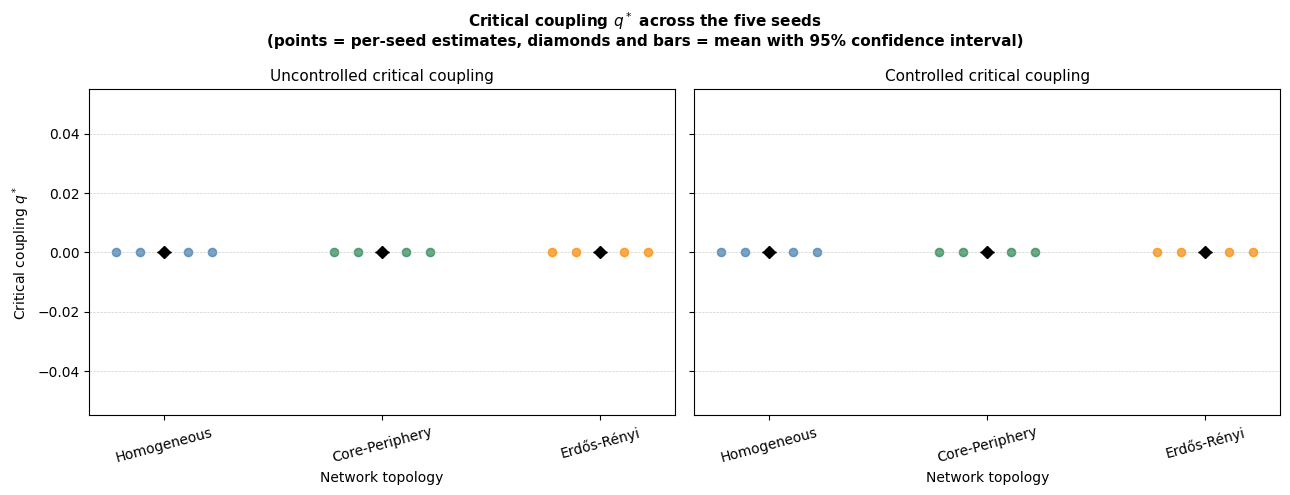

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    'Critical coupling $q^*$ across the five seeds\n'
    '(points = per-seed estimates, diamonds and bars = mean with 95% confidence interval)',
    fontsize=11,
    fontweight='bold',
)

x = np.arange(len(names))
width = 0.22
plot_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

for ax, state_key, title in [
    (axes[0], 'critical_q_uncontrolled', 'Uncontrolled critical coupling'),
    (axes[1], 'critical_q_controlled', 'Controlled critical coupling'),
]:
    for idx, topo_name in enumerate(names):
        color = plot_colors[topo_name]
        per_seed = critical_q_summary[topo_name][f'{state_key}_per_seed']
        mean = critical_q_summary[topo_name][state_key]
        ci = critical_q_summary[topo_name][f'{state_key}_ci']
        jitter = np.linspace(-width, width, num=len(per_seed)) if per_seed else []
        ax.scatter(np.full(len(per_seed), idx) + jitter, per_seed, color=color, alpha=0.75, s=35)
        ax.errorbar(
            idx,
            mean,
            yerr=[[max(0, mean - ci[0])], [max(0, ci[1] - mean)]],
            fmt='D',
            color='black',
            capsize=5,
            markersize=6,
            linewidth=1.2,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(PRETTY_NAMES, rotation=15)
    ax.set_xlabel('Network topology')
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.6)

axes[0].set_ylabel('Critical coupling $q^*$')
plt.tight_layout()
save_and_show('abm_exp4_critical_q_seed_uncertainty')

### Critical-q shift: $\Delta q^*$ per topology

The MF policy acts as a stabiliser that pushes the phase boundary to a higher interaction strength. We quantify this as $\Delta q^* = q^*_{\text{controlled}} - q^*_{\text{uncontrolled}}$ per network topology, where $q^*$ is the first $q$ at which the cascade rate crosses 50 %. A "≥" annotation means the policy fully suppressed cascades throughout the sweep, so $\Delta q^*$ is a lower bound.


C:\Users\adoni\AppData\Local\Temp\ipykernel_16656\1440009226.py:65: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[0].set_ylim(0, max(valid_dq) * 1.5)


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp4_critical_q_shift.png


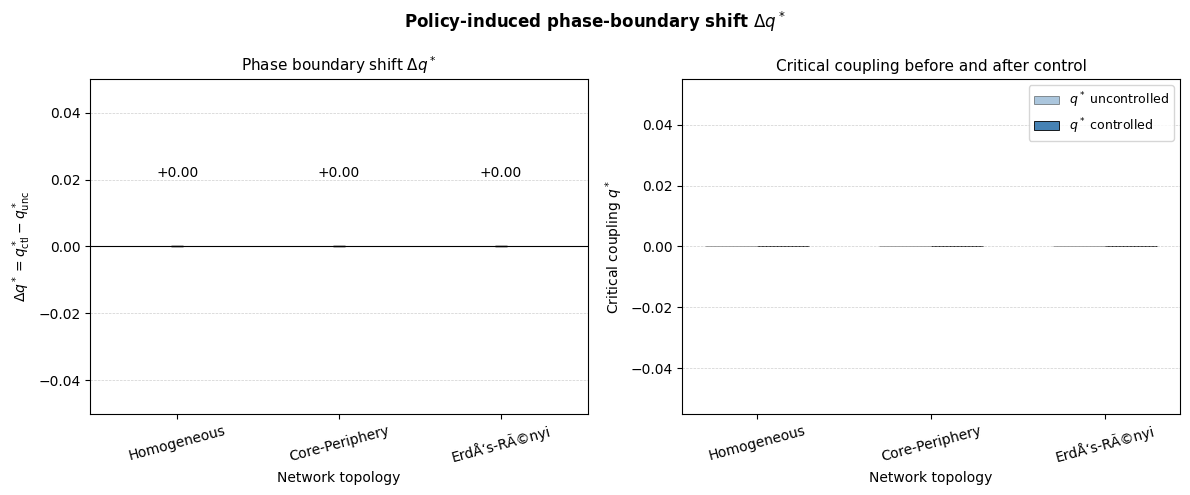


Phase boundary summary:
Topology                 q*_unc       q*_ctl          Δq*
----------------------------------------------------------
  homogeneous            0.0000       0.0000      +0.0000
  core_periphery         0.0000       0.0000      +0.0000
  erdos_renyi            0.0000       0.0000      +0.0000


In [15]:
topo_list = list(exp4.keys())
q_max_sweep = q4[-1]
topo_bar_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}
pretty = {'homogeneous': 'Homogeneous', 'core_periphery': 'Core-Periphery', 'erdos_renyi': 'ErdÅ‘s-RÃ©nyi'}

q_unc_list, q_ctl_list, delta_q_list, delta_q_ci_list, ctl_capped = [], [], [], [], []
for topo in topo_list:
    cq_u = exp4[topo].get('critical_q_uncontrolled')
    cq_c = exp4[topo].get('critical_q_controlled')
    q_unc_list.append(cq_u if cq_u is not None else float('nan'))
    capped = cq_c is None
    q_ctl_list.append(q_max_sweep if capped else cq_c)
    if capped and cq_u is not None:
        delta_q = q_max_sweep - cq_u
        delta_q_ci = [delta_q, delta_q]
    elif cq_c is not None and cq_u is not None:
        per_seed_unc = critical_q_summary[topo]['critical_q_uncontrolled_per_seed']
        per_seed_ctl = critical_q_summary[topo]['critical_q_controlled_per_seed']
        paired = [ctl - unc for unc, ctl in zip(per_seed_unc, per_seed_ctl)]
        delta_q, delta_q_ci = scalar_mean_and_ci(paired)
    else:
        delta_q = float('nan')
        delta_q_ci = [float('nan'), float('nan')]
    delta_q_list.append(delta_q)
    delta_q_ci_list.append(delta_q_ci)
    ctl_capped.append(capped)

pretty_topo_list = [pretty.get(t, t) for t in topo_list]
bar_colors = [topo_bar_colors.get(t, 'grey') for t in topo_list]

delta_err = [
    [max(0, value - ci[0]) if value == value else 0 for value, ci in zip(delta_q_list, delta_q_ci_list)],
    [max(0, ci[1] - value) if value == value else 0 for value, ci in zip(delta_q_list, delta_q_ci_list)],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    r'Policy-induced phase-boundary shift $\Delta q^*$',
    fontsize=12, fontweight='bold',
)

bars = axes[0].bar(
    pretty_topo_list,
    delta_q_list,
    color=bar_colors,
    alpha=0.85,
    edgecolor='k',
    linewidth=0.5,
    yerr=delta_err,
    capsize=4,
    error_kw={'elinewidth': 1.0, 'ecolor': '#333'},
)
axes[0].axhline(0, color='k', lw=0.8)
for bar, dq, capped in zip(bars, delta_q_list, ctl_capped):
    if dq == dq:
        label = r'$\geq$' + f'+{dq:.2f}' if capped else f'+{dq:.2f}'
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, label, ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('Network topology')
axes[0].set_ylabel(r'$\Delta q^* = q^*_{\rm ctl} - q^*_{\rm unc}$')
axes[0].set_title(r'Phase boundary shift $\Delta q^*$', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', ls='--', lw=0.5, alpha=0.6)
valid_dq = [value for value in delta_q_list if value == value]
if valid_dq:
    axes[0].set_ylim(0, max(valid_dq) * 1.5)

x = list(range(len(topo_list)))
w = 0.3
axes[1].bar([i - w / 2 for i in x], q_unc_list, width=w, color=bar_colors, alpha=0.45, label='$q^*$ uncontrolled', edgecolor='k', linewidth=0.6)
b2 = axes[1].bar([i + w / 2 for i in x], q_ctl_list, width=w, color=bar_colors, alpha=1.0, label='$q^*$ controlled', edgecolor='k', linewidth=0.6)
for capped, bar in zip(ctl_capped, b2):
    if capped:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, r'$\geq$' + f'{q_max_sweep:.2f}', ha='center', va='bottom', fontsize=9, style='italic')
axes[1].set_xticks(x)
axes[1].set_xticklabels(pretty_topo_list, rotation=15)
axes[1].set_xlabel('Network topology')
axes[1].set_ylabel('Critical coupling $q^*$')
axes[1].set_title('Critical coupling before and after control', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', ls='--', lw=0.5, alpha=0.6)

plt.tight_layout()
save_and_show('abm_exp4_critical_q_shift')

print('\nPhase boundary summary:')
print(f"{'Topology':<22} {'q*_unc':>8} {'q*_ctl':>12} {'Δq*':>12}")
print('-' * 58)
for topo, cq_u, cq_c_plot, dq, capped in zip(topo_list, q_unc_list, q_ctl_list, delta_q_list, ctl_capped):
    cq_c_str = f'≥{q_max_sweep:.4f}' if capped else f'{cq_c_plot:.4f}'
    dq_str = f'≥{dq:.4f}' if capped else f'+{dq:.4f}'
    print(f"  {topo:<20} {cq_u:>8.4f} {cq_c_str:>12} {dq_str:>12}")

## Policy robustness across initial distributions

The MF policy was trained exclusively on `case_1` ($\mu_0 \sim \mathcal{N}(0, 0.2^2)$). Here we apply the same frozen checkpoint to agents initialised under `case_2` and `case_3`, at the same calibrated interaction strength $q^*$, across all three topologies.

This tests distributional robustness: does the learned control generalise beyond the training distribution when the mean-field hypothesis is already broken by a finite, heterogeneous network?


In [16]:
CASES_ROBUST = ['case_1', 'case_2', 'case_3', 'case_4', 'case_5', 'case_6']
robust_results_by_seed = []

for seed_output in out['seed_outputs']:
    seed = seed_output['config']['args']['seed']
    checkpoint_path = (ROOT / seed_output['config']['checkpoint']).resolve()
    policy_robust = rae.load_policy_from_checkpoint(checkpoint_path, out['run_device'])
    abm_cfg_robust = ABMConfig(
        horizon=args.horizon,
        steps=args.steps,
        sigma=args.sigma,
        interaction_q=float(seed_output['calibration']['selected_q']),
        state_dim=args.state_dim,
        default_threshold=args.default_threshold,
    )
    topo_robust = rae.build_topologies(args.agents, args.core_hubs, args.er_p, out['run_device'])
    case_results = {}
    for case_name in CASES_ROBUST:
        case_results[case_name] = rae.experiment_2_controlled(
            abm_cfg_robust,
            topo_robust,
            case_name,
            args.mc_paths,
            args.state_dim,
            out['run_device'],
            policy_robust,
        )
    robust_results_by_seed.append({'seed': seed, 'results': case_results})

robust_results = {}
for case_name in CASES_ROBUST:
    robust_results[case_name] = aggregate_experiment_2(
        [{'experiment_2_controlled': item['results'][case_name]} for item in robust_results_by_seed]
    )

for case_name in CASES_ROBUST:
    rate_red = {name: f"{robust_results[case_name][name]['cascade_reduction']:.3f}" for name in names}
    size_red = {name: f"{robust_results[case_name][name]['cascade_size_reduction']:.3f}" for name in names}
    print(f'{case_name}  rate_reduction={rate_red}')
    print(f'       size_reduction={size_red}')

case_1  rate_reduction={'homogeneous': '0.000', 'core_periphery': '0.000', 'erdos_renyi': '0.000'}
       size_reduction={'homogeneous': '3.490', 'core_periphery': '3.229', 'erdos_renyi': '3.383'}
case_2  rate_reduction={'homogeneous': '0.014', 'core_periphery': '0.013', 'erdos_renyi': '0.011'}
       size_reduction={'homogeneous': '1.384', 'core_periphery': '1.293', 'erdos_renyi': '1.303'}
case_3  rate_reduction={'homogeneous': '0.000', 'core_periphery': '0.000', 'erdos_renyi': '0.000'}
       size_reduction={'homogeneous': '3.264', 'core_periphery': '3.358', 'erdos_renyi': '3.340'}
case_4  rate_reduction={'homogeneous': '0.000', 'core_periphery': '0.000', 'erdos_renyi': '0.000'}
       size_reduction={'homogeneous': '3.618', 'core_periphery': '3.595', 'erdos_renyi': '3.451'}
case_5  rate_reduction={'homogeneous': '0.000', 'core_periphery': '0.000', 'erdos_renyi': '0.000'}
       size_reduction={'homogeneous': '3.700', 'core_periphery': '3.484', 'erdos_renyi': '3.554'}
case_6  rate_re

Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_policy_robustness.png


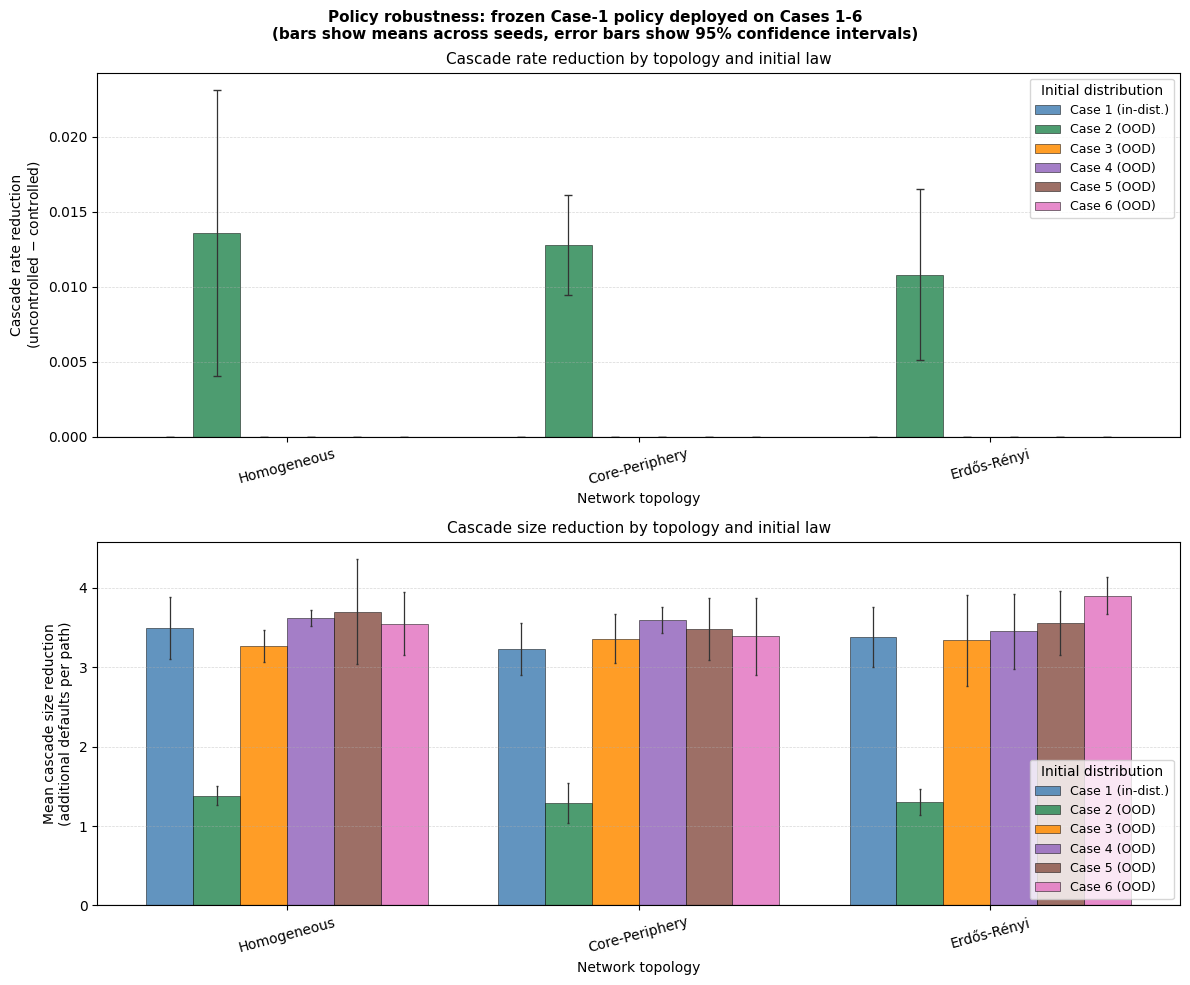


Robustness summary with 95% confidence intervals:

case_1:
  Homogeneous: rate Δ=0.000 [0.000, 0.000]  size Δ=3.490 [3.101, 3.879]
  Core-Periphery: rate Δ=0.000 [0.000, 0.000]  size Δ=3.229 [2.902, 3.556]
  Erdős-Rényi: rate Δ=0.000 [0.000, 0.000]  size Δ=3.383 [3.004, 3.762]

case_2:
  Homogeneous: rate Δ=0.014 [0.004, 0.023]  size Δ=1.384 [1.266, 1.502]
  Core-Periphery: rate Δ=0.013 [0.009, 0.016]  size Δ=1.293 [1.044, 1.542]
  Erdős-Rényi: rate Δ=0.011 [0.005, 0.017]  size Δ=1.303 [1.145, 1.462]

case_3:
  Homogeneous: rate Δ=0.000 [0.000, 0.000]  size Δ=3.264 [3.061, 3.468]
  Core-Periphery: rate Δ=0.000 [0.000, 0.000]  size Δ=3.358 [3.053, 3.663]
  Erdős-Rényi: rate Δ=0.000 [0.000, 0.000]  size Δ=3.340 [2.768, 3.911]

case_4:
  Homogeneous: rate Δ=0.000 [0.000, 0.000]  size Δ=3.618 [3.515, 3.720]
  Core-Periphery: rate Δ=0.000 [0.000, 0.000]  size Δ=3.595 [3.436, 3.755]
  Erdős-Rényi: rate Δ=0.000 [0.000, 0.000]  size Δ=3.451 [2.983, 3.919]

case_5:
  Homogeneous: rate Δ=0.000 

In [17]:
pretty_names = PRETTY_NAMES
case_colors = {'case_1': 'steelblue', 'case_2': 'seagreen', 'case_3': 'darkorange',
               'case_4': '#9467bd', 'case_5': '#8c564b', 'case_6': '#e377c2'}
case_labels = {'case_1': 'Case 1 (in-dist.)', 'case_2': 'Case 2 (OOD)', 'case_3': 'Case 3 (OOD)',
               'case_4': 'Case 4 (OOD)', 'case_5': 'Case 5 (OOD)', 'case_6': 'Case 6 (OOD)'}
x = list(range(len(names)))
n_cases = len(CASES_ROBUST)
w = 0.8 / n_cases

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle(
    'Policy robustness: frozen Case-1 policy deployed on Cases 1-6\n'
    '(bars show means across seeds, error bars show 95% confidence intervals)',
    fontsize=11, fontweight='bold',
)

for case_idx, case_name in enumerate(CASES_ROBUST):
    offset = (case_idx - (n_cases - 1) / 2) * w
    rate_reductions = [robust_results[case_name][name]['cascade_reduction'] for name in names]
    rate_ci = [robust_results[case_name][name].get('cascade_reduction_ci', [value, value]) for name, value in zip(names, rate_reductions)]
    rate_err = [[max(0, value - ci[0]) for value, ci in zip(rate_reductions, rate_ci)], [max(0, ci[1] - value) for value, ci in zip(rate_reductions, rate_ci)]]

    size_reductions = [robust_results[case_name][name]['cascade_size_reduction'] for name in names]
    size_ci = [robust_results[case_name][name].get('cascade_size_reduction_ci', [value, value]) for name, value in zip(names, size_reductions)]
    size_err = [[max(0, value - ci[0]) for value, ci in zip(size_reductions, size_ci)], [max(0, ci[1] - value) for value, ci in zip(size_reductions, size_ci)]]

    color = case_colors[case_name]
    xpos = [xi + offset for xi in x]
    axes[0].bar(
        xpos,
        rate_reductions,
        width=w,
        label=case_labels[case_name],
        color=color,
        alpha=0.85,
        edgecolor='k',
        linewidth=0.4,
        yerr=rate_err,
        capsize=3,
        error_kw={'elinewidth': 0.9, 'ecolor': '#333'},
    )
    axes[1].bar(
        xpos,
        size_reductions,
        width=w,
        label=case_labels[case_name],
        color=color,
        alpha=0.85,
        edgecolor='k',
        linewidth=0.4,
        yerr=size_err,
        capsize=1,
        error_kw={'elinewidth': 0.9, 'ecolor': '#333'},
    )

for ax, ylabel, title in zip(
    axes,
    ['Cascade rate reduction\n(uncontrolled $-$ controlled)', 'Mean cascade size reduction\n(additional defaults per path)'],
    ['Cascade rate reduction by topology and initial law', 'Cascade size reduction by topology and initial law'],
):
    ax.set_xticks(x)
    ax.set_xticklabels(pretty_names, rotation=15)
    ax.set_xlabel('Network topology')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(title='Initial distribution', fontsize=9)
    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.5)

plt.tight_layout()
save_and_show('abm_policy_robustness')

print('\nRobustness summary with 95% confidence intervals:')
for case_name in CASES_ROBUST:
    print(f'\n{case_name}:')
    for name, pretty_name in zip(names, pretty_names):
        rate = robust_results[case_name][name]['cascade_reduction']
        rate_ci = robust_results[case_name][name].get('cascade_reduction_ci', [rate, rate])
        size = robust_results[case_name][name]['cascade_size_reduction']
        size_ci = robust_results[case_name][name].get('cascade_size_reduction_ci', [size, size])
        print(
            f"  {pretty_name}: rate Δ={rate:.3f} [{rate_ci[0]:.3f}, {rate_ci[1]:.3f}]  "
            f"size Δ={size:.3f} [{size_ci[0]:.3f}, {size_ci[1]:.3f}]"
        )

## Multi-sigma comparison

The primary ABM experiments (Exp 1--4) run at $\sigma = 1.0$, matching the training noise level.

Here we extend the analysis by sweeping $(\sigma, q)$ jointly on the homogeneous topology, using three noise levels $\sigma \in \{0.2, 0.5, 1.0\}$ and coupling $q$ from 0.2 to 2.0.  At larger $\sigma$ the inherent volatility of each agent is higher, driving the cascade rate towards $\approx 100\%$ for all $q$ values and compressing the policy's visible effect.


In [18]:
import importlib
importlib.reload(rae)

SUBCRIT_SIGMAS = [0.2, 0.5, 1.0]
SUBCRIT_Q_STEPS = 19
subcrit_q_sweep = torch.linspace(0.2, 2.0, SUBCRIT_Q_STEPS).tolist()

exp5_by_seed = []
for seed_output in out['seed_outputs']:
    checkpoint_path = (ROOT / seed_output['config']['checkpoint']).resolve()
    policy_subcrit = rae.load_policy_from_checkpoint(checkpoint_path, out['run_device'])
    calib_config = ABMConfig(
        horizon=args.horizon,
        steps=args.steps,
        sigma=args.sigma,
        interaction_q=float(seed_output['calibration']['selected_q']),
        state_dim=args.state_dim,
        default_threshold=args.default_threshold,
    )
    exp5_seed = rae.experiment_5_subcritical_rate_comparison(
        calib_config,
        SUBCRIT_SIGMAS,
        subcrit_q_sweep,
        args.agents,
        args.case,
        args.mc_paths,
        args.state_dim,
        out['run_device'],
        policy_subcrit,
    )
    exp5_by_seed.append(exp5_seed)

exp5 = aggregate_experiment_5(exp5_by_seed)

for row in exp5:
    cq_unc_ci = row.get('critical_q_uncontrolled_ci', [None, None])
    cq_ctl_ci = row.get('critical_q_controlled_ci', [None, None])
    max_red = max(r['rate_reduction'] for r in row['q_sweep'])
    print(
        f"sigma={row['sigma']:.1f}  "
        f"cq_unc={row['critical_q_uncontrolled']} [{cq_unc_ci[0]}, {cq_unc_ci[1]}]  "
        f"cq_ctl={row['critical_q_controlled']} [{cq_ctl_ci[0]}, {cq_ctl_ci[1]}]"
    )
    print(f'         max rate reduction: {max_red:.3f}')

sigma=0.2  cq_unc=0.20000000298023224 [0.20000000298023224, 0.20000000298023224]  cq_ctl=None [None, None]
         max rate reduction: 0.472
sigma=0.5  cq_unc=0.20000000298023224 [0.20000000298023224, 0.20000000298023224]  cq_ctl=0.20000000298023224 [0.20000000298023224, 0.20000000298023224]
         max rate reduction: 0.166
sigma=1.0  cq_unc=0.20000000298023224 [0.20000000298023224, 0.20000000298023224]  cq_ctl=0.20000000298023224 [0.20000000298023224, 0.20000000298023224]
         max rate reduction: 0.000


Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_exp5_subcritical_rate_reduction.png


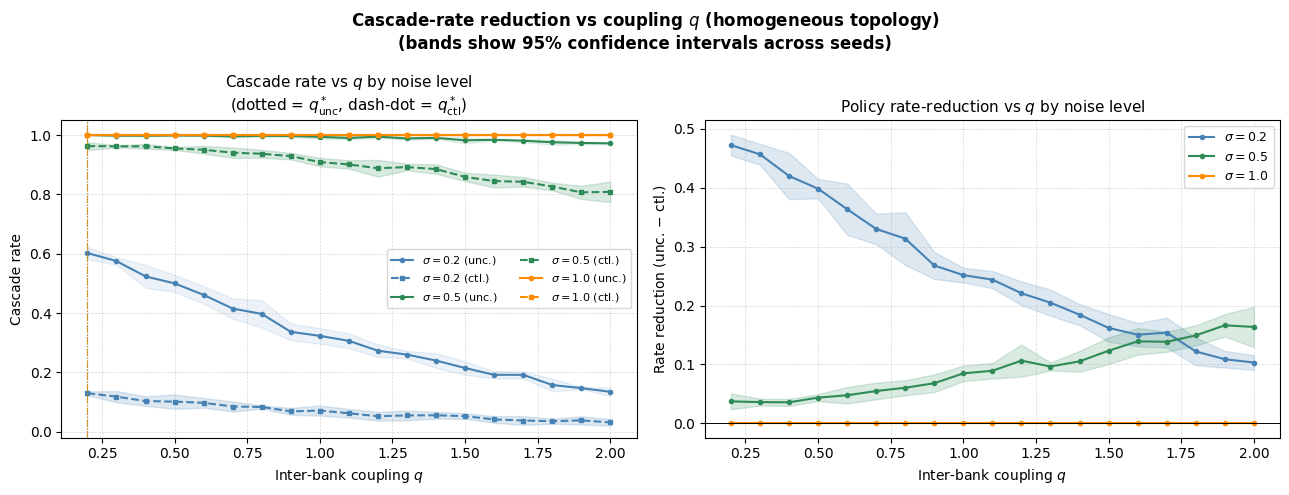


Rate-reduction summary table:
 sigma  q=0.2  q=0.5  q=0.8  q=1.1  q=1.4  q=1.7  q=2.0
   0.2  +0.472  +0.398  +0.314  +0.244  +0.184  +0.154  +0.103
   0.5  +0.037  +0.044  +0.060  +0.089  +0.105  +0.138  +0.164
   1.0  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000


In [19]:
sigma_colors = {0.2: 'steelblue', 0.5: 'seagreen', 1.0: 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Cascade-rate reduction vs coupling $q$ (homogeneous topology)\n'
    '(bands show 95% confidence intervals across seeds)',
    fontsize=12, fontweight='bold',
)

for row in exp5:
    sigma = row['sigma']
    color = sigma_colors.get(sigma, 'grey')
    qs = [r['q'] for r in row['q_sweep']]
    u_rates = [r['uncontrolled_cascade_rate'] for r in row['q_sweep']]
    c_rates = [r['controlled_cascade_rate'] for r in row['q_sweep']]
    reductions = [r['rate_reduction'] for r in row['q_sweep']]

    u_lo = [r.get('uncontrolled_cascade_rate_ci', [value, value])[0] for r, value in zip(row['q_sweep'], u_rates)]
    u_hi = [r.get('uncontrolled_cascade_rate_ci', [value, value])[1] for r, value in zip(row['q_sweep'], u_rates)]
    c_lo = [r.get('controlled_cascade_rate_ci', [value, value])[0] for r, value in zip(row['q_sweep'], c_rates)]
    c_hi = [r.get('controlled_cascade_rate_ci', [value, value])[1] for r, value in zip(row['q_sweep'], c_rates)]
    red_lo = [r.get('rate_reduction_ci', [value, value])[0] for r, value in zip(row['q_sweep'], reductions)]
    red_hi = [r.get('rate_reduction_ci', [value, value])[1] for r, value in zip(row['q_sweep'], reductions)]

    label = f'$\\sigma={sigma}$'
    axes[0].plot(qs, u_rates, color=color, lw=1.5, marker='o', markersize=3, label=f'{label} (unc.)')
    axes[0].fill_between(qs, u_lo, u_hi, color=color, alpha=0.10)
    axes[0].plot(qs, c_rates, color=color, lw=1.5, marker='s', markersize=3, ls='--', label=f'{label} (ctl.)')
    axes[0].fill_between(qs, c_lo, c_hi, color=color, alpha=0.18)

    cq_u = row['critical_q_uncontrolled']
    cq_c = row['critical_q_controlled']
    if cq_u is not None:
        axes[0].axvline(cq_u, color=color, ls=':', lw=0.8, alpha=0.6)
    if cq_c is not None:
        axes[0].axvline(cq_c, color=color, ls='-.', lw=0.8, alpha=0.6)

    axes[1].plot(qs, reductions, color=color, lw=1.5, marker='o', markersize=3, label=label)
    axes[1].fill_between(qs, red_lo, red_hi, color=color, alpha=0.18)

axes[0].set_xlabel('Inter-bank coupling $q$')
axes[0].set_ylabel('Cascade rate')
axes[0].set_ylim(-0.02, 1.05)
axes[0].set_title(
    'Cascade rate vs $q$ by noise level\n'
    r'(dotted = $q^*_{\rm unc}$, dash-dot = $q^*_{\rm ctl}$)',
    fontsize=11,
)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, ls='--', lw=0.5, alpha=0.5)

axes[1].set_xlabel('Inter-bank coupling $q$')
axes[1].set_ylabel('Rate reduction (unc. $-$ ctl.)')
axes[1].axhline(0, color='k', lw=0.7)
axes[1].set_title('Policy rate-reduction vs $q$ by noise level', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, ls='--', lw=0.5, alpha=0.5)

plt.tight_layout()
save_and_show('abm_exp5_subcritical_rate_reduction')

print('\nRate-reduction summary table:')
header = f"{'sigma':>6}  " + '  '.join(f"q={r['q']:.1f}" for r in exp5[0]['q_sweep'][::3])
print(header)
for row in exp5:
    vals = '  '.join(f"{r['rate_reduction']:+.3f}" for r in row['q_sweep'][::3])
    print(f"{row['sigma']:>6.1f}  {vals}")

## Selected encoder summary

The notebook screens the bin and cylindrical encoders first, using the Case-1 policy-effectiveness objective across all five seeds. The higher-performing encoder is then kept for every downstream ABM experiment.

Saved figure: C:\Users\adoni\Desktop\Interactions\project\results\figures\abm\abm_encoder_screening.png


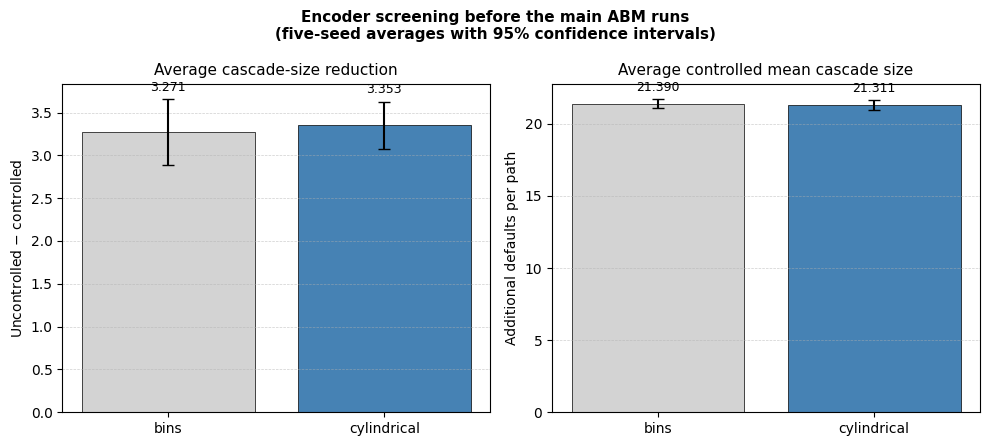

Selected encoder: cylindrical
Seeds used: [7, 9, 11, 13, 21]

Encoder screening summary:
Encoder           Avg reduction                   95% CI     Avg ctl size                   95% CI
--------------------------------------------------------------------------------------------------------
bins                      3.271 [2.889, 3.653]           21.390 [21.091, 21.689]
cylindrical               3.353 [3.079, 3.626]           21.311 [20.983, 21.639]


In [20]:
encoder_screen_rows = []
for summary in out['encoder_screen']:
    ci = summary['avg_size_reduction_ci']
    size_ci = summary['avg_controlled_size_ci']
    encoder_screen_rows.append({
        'encoder': summary['encoder'],
        'avg_reduction': summary['avg_size_reduction'],
        'avg_reduction_ci_lo': ci[0],
        'avg_reduction_ci_hi': ci[1],
        'avg_size': summary['avg_controlled_size'],
        'avg_size_ci_lo': size_ci[0],
        'avg_size_ci_hi': size_ci[1],
    })

labels = [row['encoder'] for row in encoder_screen_rows]
reductions = [row['avg_reduction'] for row in encoder_screen_rows]
reduction_err = [
    [max(0, value - row['avg_reduction_ci_lo']) for value, row in zip(reductions, encoder_screen_rows)],
    [max(0, row['avg_reduction_ci_hi'] - value) for value, row in zip(reductions, encoder_screen_rows)],
]
controlled_sizes = [row['avg_size'] for row in encoder_screen_rows]
size_err = [
    [max(0, value - row['avg_size_ci_lo']) for value, row in zip(controlled_sizes, encoder_screen_rows)],
    [max(0, row['avg_size_ci_hi'] - value) for value, row in zip(controlled_sizes, encoder_screen_rows)],
]
colors = ['steelblue' if label == out['selected_encoder'] else 'lightgrey' for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle(
    'Encoder screening before the main ABM runs\n'
    '(five-seed averages with 95% confidence intervals)',
    fontsize=11,
    fontweight='bold',
)

bars0 = axes[0].bar(labels, reductions, color=colors, edgecolor='k', linewidth=0.5, yerr=reduction_err, capsize=4)
axes[0].bar_label(bars0, fmt='%.3f', padding=4, fontsize=9)
axes[0].set_title('Average cascade-size reduction', fontsize=11)
axes[0].set_ylabel('Uncontrolled $-$ controlled')
axes[0].grid(axis='y', ls='--', lw=0.5, alpha=0.6)

bars1 = axes[1].bar(labels, controlled_sizes, color=colors, edgecolor='k', linewidth=0.5, yerr=size_err, capsize=4)
axes[1].bar_label(bars1, fmt='%.3f', padding=4, fontsize=9)
axes[1].set_title('Average controlled mean cascade size', fontsize=11)
axes[1].set_ylabel('Additional defaults per path')
axes[1].grid(axis='y', ls='--', lw=0.5, alpha=0.6)

plt.tight_layout()
save_and_show('abm_encoder_screening')

print(f"Selected encoder: {out['selected_encoder']}")
print(f"Seeds used: {out['available_seeds']}")
print('\nEncoder screening summary:')
print(f"{'Encoder':<14} {'Avg reduction':>16} {'95% CI':>24} {'Avg ctl size':>16} {'95% CI':>24}")
print('-' * 104)
for summary in out['encoder_screen']:
    red_ci = summary['avg_size_reduction_ci']
    size_ci = summary['avg_controlled_size_ci']
    print(
        f"{summary['encoder']:<14} {summary['avg_size_reduction']:>16.3f} "
        f"[{red_ci[0]:.3f}, {red_ci[1]:.3f}] "
        f"{summary['avg_controlled_size']:>16.3f} "
        f"[{size_ci[0]:.3f}, {size_ci[1]:.3f}]"
    )